# Простые методы предсказания ВР

## Библиотеки экосистемы анализа временных рядов Nixtla 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, smape, mase

In [3]:
# def matplotlib2GOST:
plt.rcParams.update({
    # ШРИФТ
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 11,                      # ГОСТ: 10–12 pt

    # ОСИ И ПОДПИСИ
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,

    # РАЗМЕР ФИГУРЫ (A4, отчёты)
    # "figure.figsize": (6.5, 4.0),         # ~16.5 × 10 см
    "figure.figsize": (12, 3.0),         
    "figure.dpi": 150,
    "savefig.dpi": 300,

    # СОХРАНЕНИЕ
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,

    # ЛИНИИ И ОСИ
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "lines.linewidth": 1.5,
    "patch.linewidth": 1.0,

    # СЕТКА
    "axes.grid": True,                   # ГОСТ: обычно без сетки
    "axes.axisbelow": True,

    # TEX
    "text.usetex": False,
})


### Загрузка данных

Загрузим данные

In [4]:
df_ = pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df_.head(1)

,Consumption,Wind,Solar,temperature,radiation_direct_horizontal,hour,month,day_of_week,Consumption_detrended,season,day_of_week_str,daylight_duration,week,is_holiday,Consumption_resid,Wind_resid,Solar_resid,temperature_resid,radiation_direct_horizontal_resid
time,,,,,,,,,,,,,,,,,,,
2015-01-01,41.151,8.852,0.071,-0.981,0.0,0,1,3,-7.29271,Winter,Thu,7.921998,1,True,0.136794,0.610749,0.382488,-4.475639,-7.584582


Выберем ВР для дальнейшего анализа

In [5]:
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']

Для простоты освоения инструментов возьмам данные только с самым длинным периодом. То есть усредрим все более быстрые колебания. Данные будем рассматривать с шагом в неделю. У нас остается 1 сезонная компонента со значением сезона - 53 недели (1 год)

In [6]:
y = df_.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
})

y = y.iloc[1:-2]

### Приведение данных к long формату

Преобразуем временной ряд к стандартному для `Nixtla` виду `panel`. 

Такой формат данных это по сути т.н. long данные - когда все ВР составлены в столбец. И каждый ВР выбирается по уникальному идентификатору.

Для этого создадим соответствующие столбцы:
* `ds` - временные метки.
* `unique_id` - название временного ряда. Это будет полезно при использовании многопеременных или иерархических временных рядов.
* `y` - целевая переменная ВР. В случае ногопеременных или иерархических временных рядов метки будут разделяться по их `unique_id`.

Такой формат [с укажанием id каждой записи](https://nixtlaverse.nixtla.io/neuralforecast/examples/data_format.html) представления временных рядов известен как [<tt>long format</tt>](https://www.theanalysisfactor.com/wide-and-long-data/).

In [7]:
ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

,unique_id,ds,y
452,Wind,2018-09-23,2815.505
424,Wind,2018-03-11,1972.440
592,Solar,2016-06-12,1226.052
401,Wind,2017-10-01,1114.664
68,Consumption,2016-05-01,9220.497


Проверим, что у нас действительно все датасеты е

In [8]:
panel_df['unique_id'].unique()

array(['Consumption', 'Wind', 'Solar'], dtype=object)

Получим частоту для дальнейшей работы

In [9]:
FREQ = y.index.freq
FREQ

<Week: weekday=6>

Проверим значенипе сезонности при помощи утилиты `find_season_length`

In [10]:
from coreforecast.seasonal import find_season_length

In [11]:
SEASON = find_season_length(y['Consumption'].values, max_season_length = 55)
SEASON

52

Также попробуем добавить экзогенные переменные. Они будут добавляться как дополнительные столбцы где для будут дублироваться для каждого `'unique_id'` по сопостовлению временных меток `ds`

In [12]:
df_exog = y[exog_cols].reset_index()
df_exog['ds'] = date_index
panel_df = panel_df.merge(df_exog, on='ds', how='left')
panel_df = panel_df[[*base_cols, *exog_cols]]
panel_df = panel_df.rename(columns = {'radiation_direct_horizontal':'radiation'})

panel_df.head(2)

,unique_id,ds,y,temperature,radiation
0,Consumption,2015-01-11,9440.105,2.488536,5.554645
1,Consumption,2015-01-18,9689.010,3.012375,7.504608


### Визуализация Временных рядов

Для визуализации ВР воспользуемся функцией [`plot_series`](https://nixtlaverse.nixtla.io/utilsforecast/plotting.html#plot-series) из библиотеки [`utilsforecast`](https://nixtlaverse.nixtla.io/utilsforecast). Функция имеет несколько "движков", в зависимости от них настройки будут разными. 

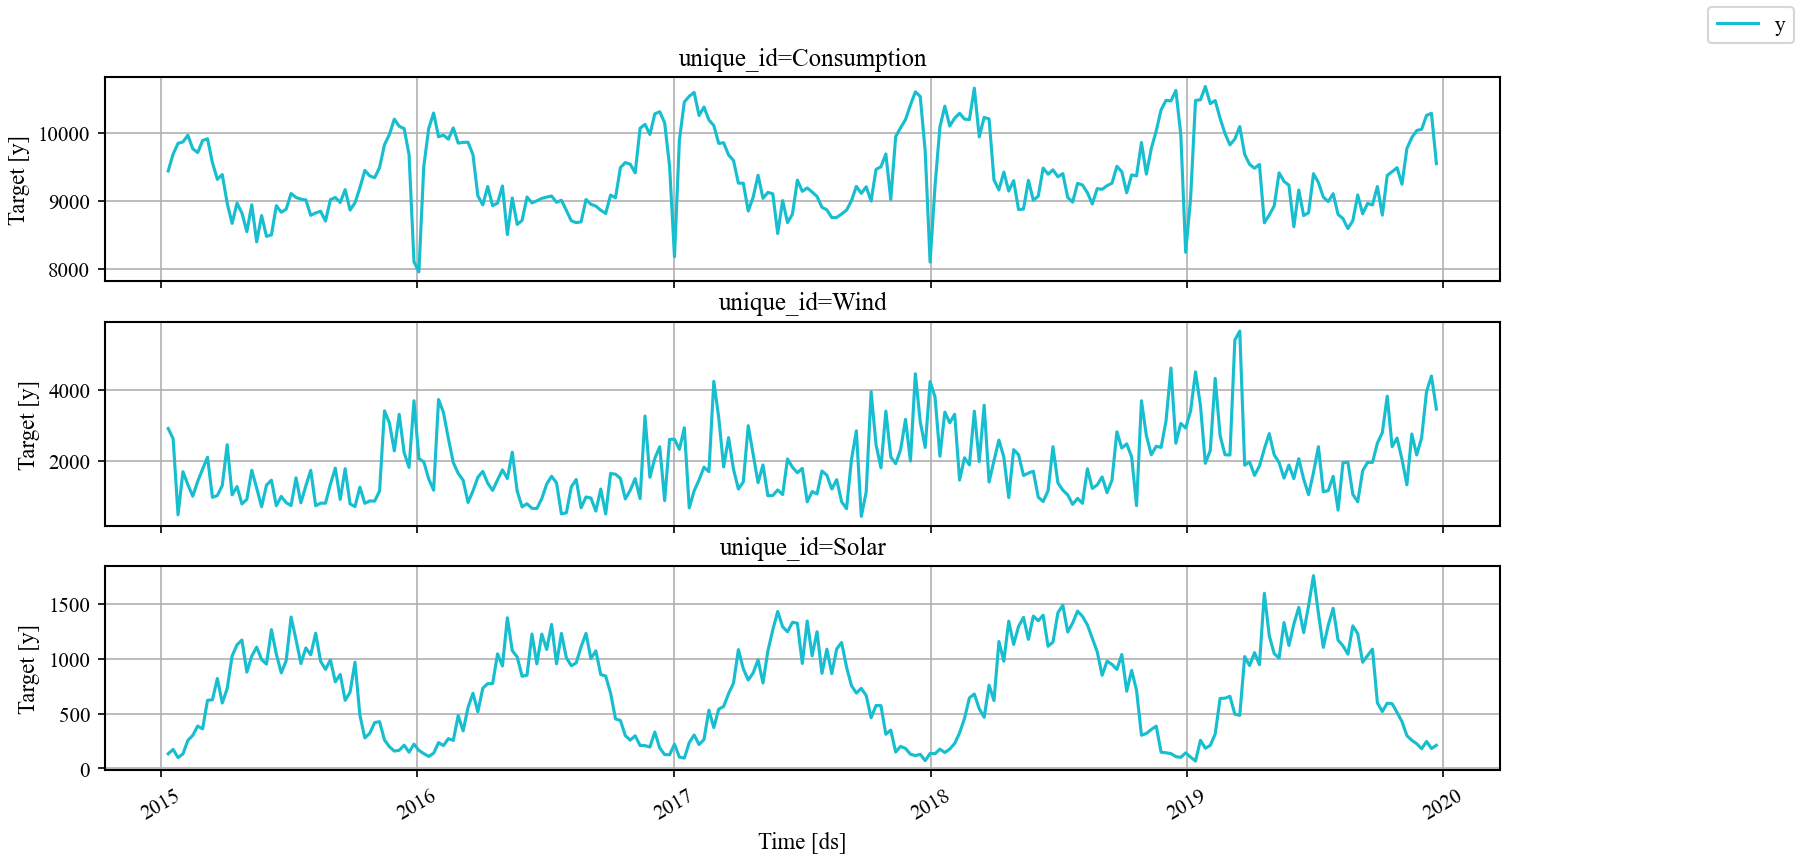

In [13]:
n_rows = len(panel_df['unique_id'].unique())
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)
plot_series(panel_df, ax = ax)

Также можно поменять движок на plotly 

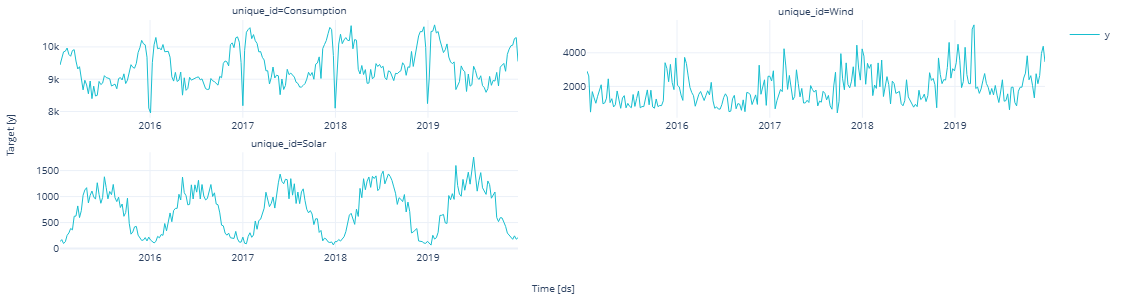

In [14]:
fig = plot_series(panel_df, engine='plotly',)
fig.update_layout(width=900,height=300)
fig

### Train Test Split

Разделим ВР на тренировочную и тестовую части. К сожалению на сегодня это возможно только в ручном режиме

In [15]:
FH = int(0.42 * y.shape[0])

In [16]:
df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

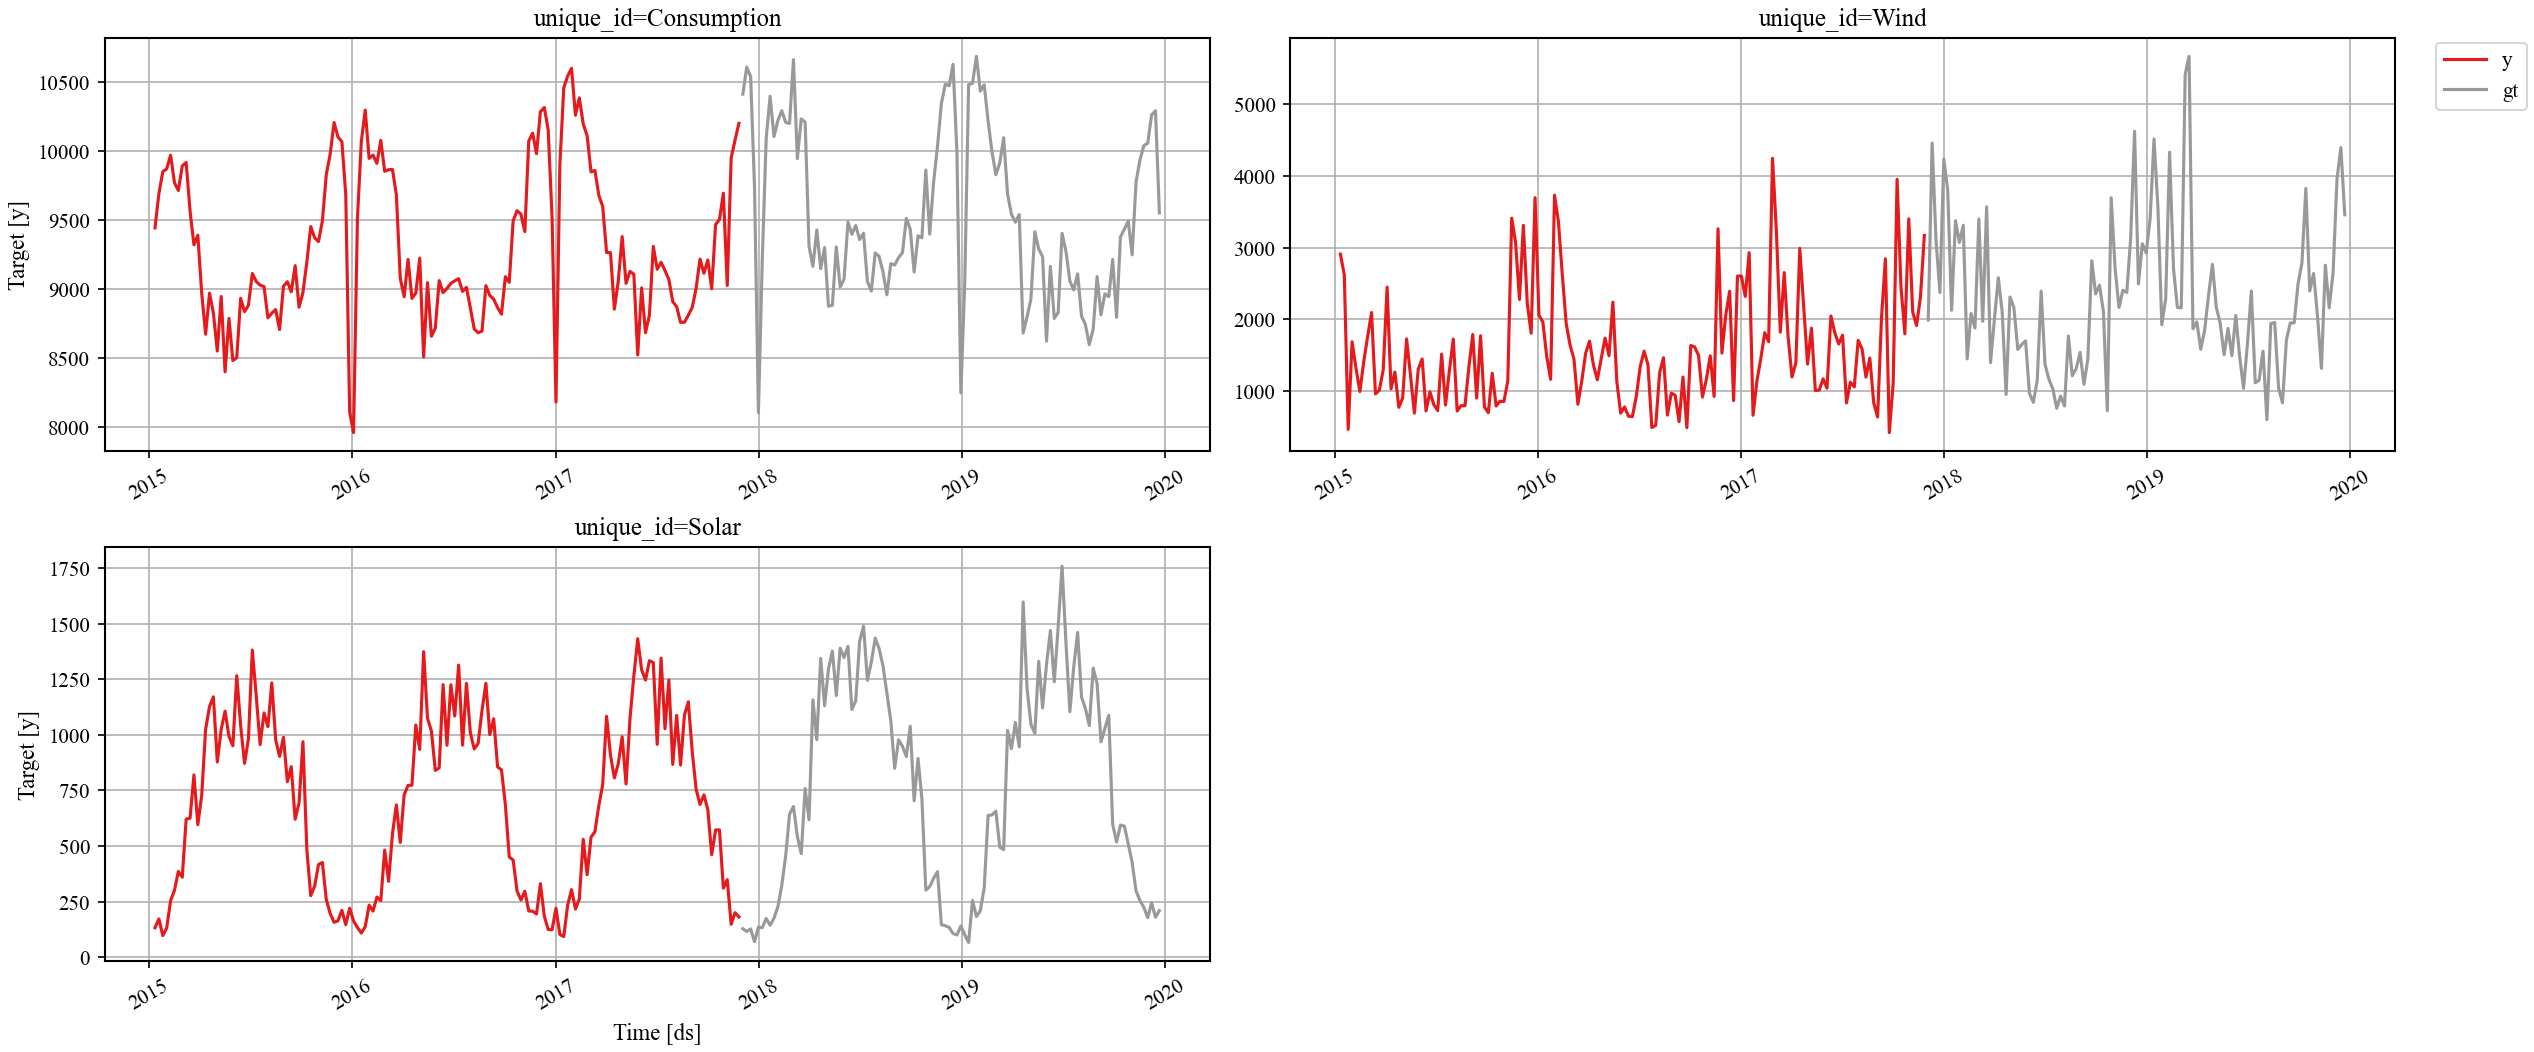

In [17]:
plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

## Оценка возможностей использования наивных моделей

### Выбор моделей

#### Базовые модели

[Полный список моделей](https://nixtlaverse.nixtla.io/statsforecast/src/core/models_intro.html) тут. Воспользуемся только [базовыми моделями](https://nixtlaverse.nixtla.io/statsforecast/src/core/models_intro.html#baseline-models).


В рамках данного занятия мы рассмотрим наиболее [простые алгоритмы предсказания](https://forecasting-encyclopedia.com/theory.html#introduction_to_the_theory_of_forecasting), которые условно разделим на:
* **Наивные методы предсказания** [(`NaiveForecasters`)](https://otexts.com/fpp3/simple-methods.html), позволяющие оценивть будущие значения как некоторые простые преобразования имеющихся значений ВР.
* **Подход на основе моделей экспоненциального сглаживания** [Exponential smoothing](https://otexts.com/fpp3/taxonomy.html) и [модфикаций подхода](https://openforecast.org/adam/exponential-smoothing.html).
* **Методы с использованием** [регрессионных подходов](https://otexts.com/fpp3/regression.html) как простых, так и [современных](https://otexts.com/fpp3/prophet.html).

__Наивные методы__ (например, прогноз «последнее значение») нужны как базовая точка отсчёта.
Они показывают минимальный уровень ошибки, с которым должна справляться любая более сложная модель. Если сложная модель хуже наивной — значит, что-то не так с данными или подходом.

Модели зададим списком

In [18]:
from statsforecast.models import (Naive, WindowAverage, HistoricAverage, 
                                    RandomWalkWithDrift, SeasonalWindowAverage, SeasonalNaive)

models=[Naive(), 
        # WindowAverage(window_size=SEASON),
        # HistoricAverage(),
        RandomWalkWithDrift(),
        # SeasonalWindowAverage(season_length=SEASON, window_size=SEASON),
        SeasonalNaive(season_length=SEASON)]

#### Класс StatsForecast

[Класс StatsForecast](https://nixtlaverse.nixtla.io/statsforecast/docs/getting-started/getting_started_short.html) - основной класс в библиотеке. Класс предоставляет удобный и унифицированный интерфейс, [частично совместимый](https://nixtlaverse.nixtla.io/statsforecast/src/core/models.html#using-scikit-learn-models) с API библиотеки `scikit-learn`. Это означает, что вы можете создавать экземпляр модели, вызывать методы `.fit()` и `.predict()`, а также позволяет получать доступ к обученным параметрам — аналогично как при работе с моделями из `sklearn`.

Такой подход особенно полезен, когда:
* не требуется максимальная скорость обработки,
* нужно проанализировать подогнанные значения (`fitted values`),
* необходимо глубже понять поведение модели и её внутренние параметры.

In [19]:
# Configure baseline models
sf_base = StatsForecast(
    models=models,
    freq=FREQ,
)
sf_base.fit(df=df_train)
fcst_base = sf_base.predict(h=FH)

fcst_base.head(1)

,unique_id,ds,Naive,RWD,SeasonalNaive
0,Consumption,2017-12-03,10197.404,10202.45266,10281.267


Видно, что обученная модель создает колонки под каждую из моделей.

В `StatsForecast` можно для ускорения объеденить продцедуры `.fit()` и `.predict()` в общую процедуру `forecast`

In [20]:
fcst_base = sf_base.forecast(df=df_train, h=FH)

Соберем датасет для оценки качества, добавив к тестовому датасету результаты предсказания его значений

In [21]:
eval_base = df_test.merge(fcst_base, on=['unique_id', 'ds'])
eval_base.head(2)

,unique_id,ds,y,Naive,RWD,SeasonalNaive
0,Consumption,2017-12-03,10409.045,10197.404,10202.45266,10281.267
1,Consumption,2017-12-10,10604.489,10197.404,10207.50132,10311.769


Проведем визуализацию результатов. Трейн будеми визуализировать только на 1 период.

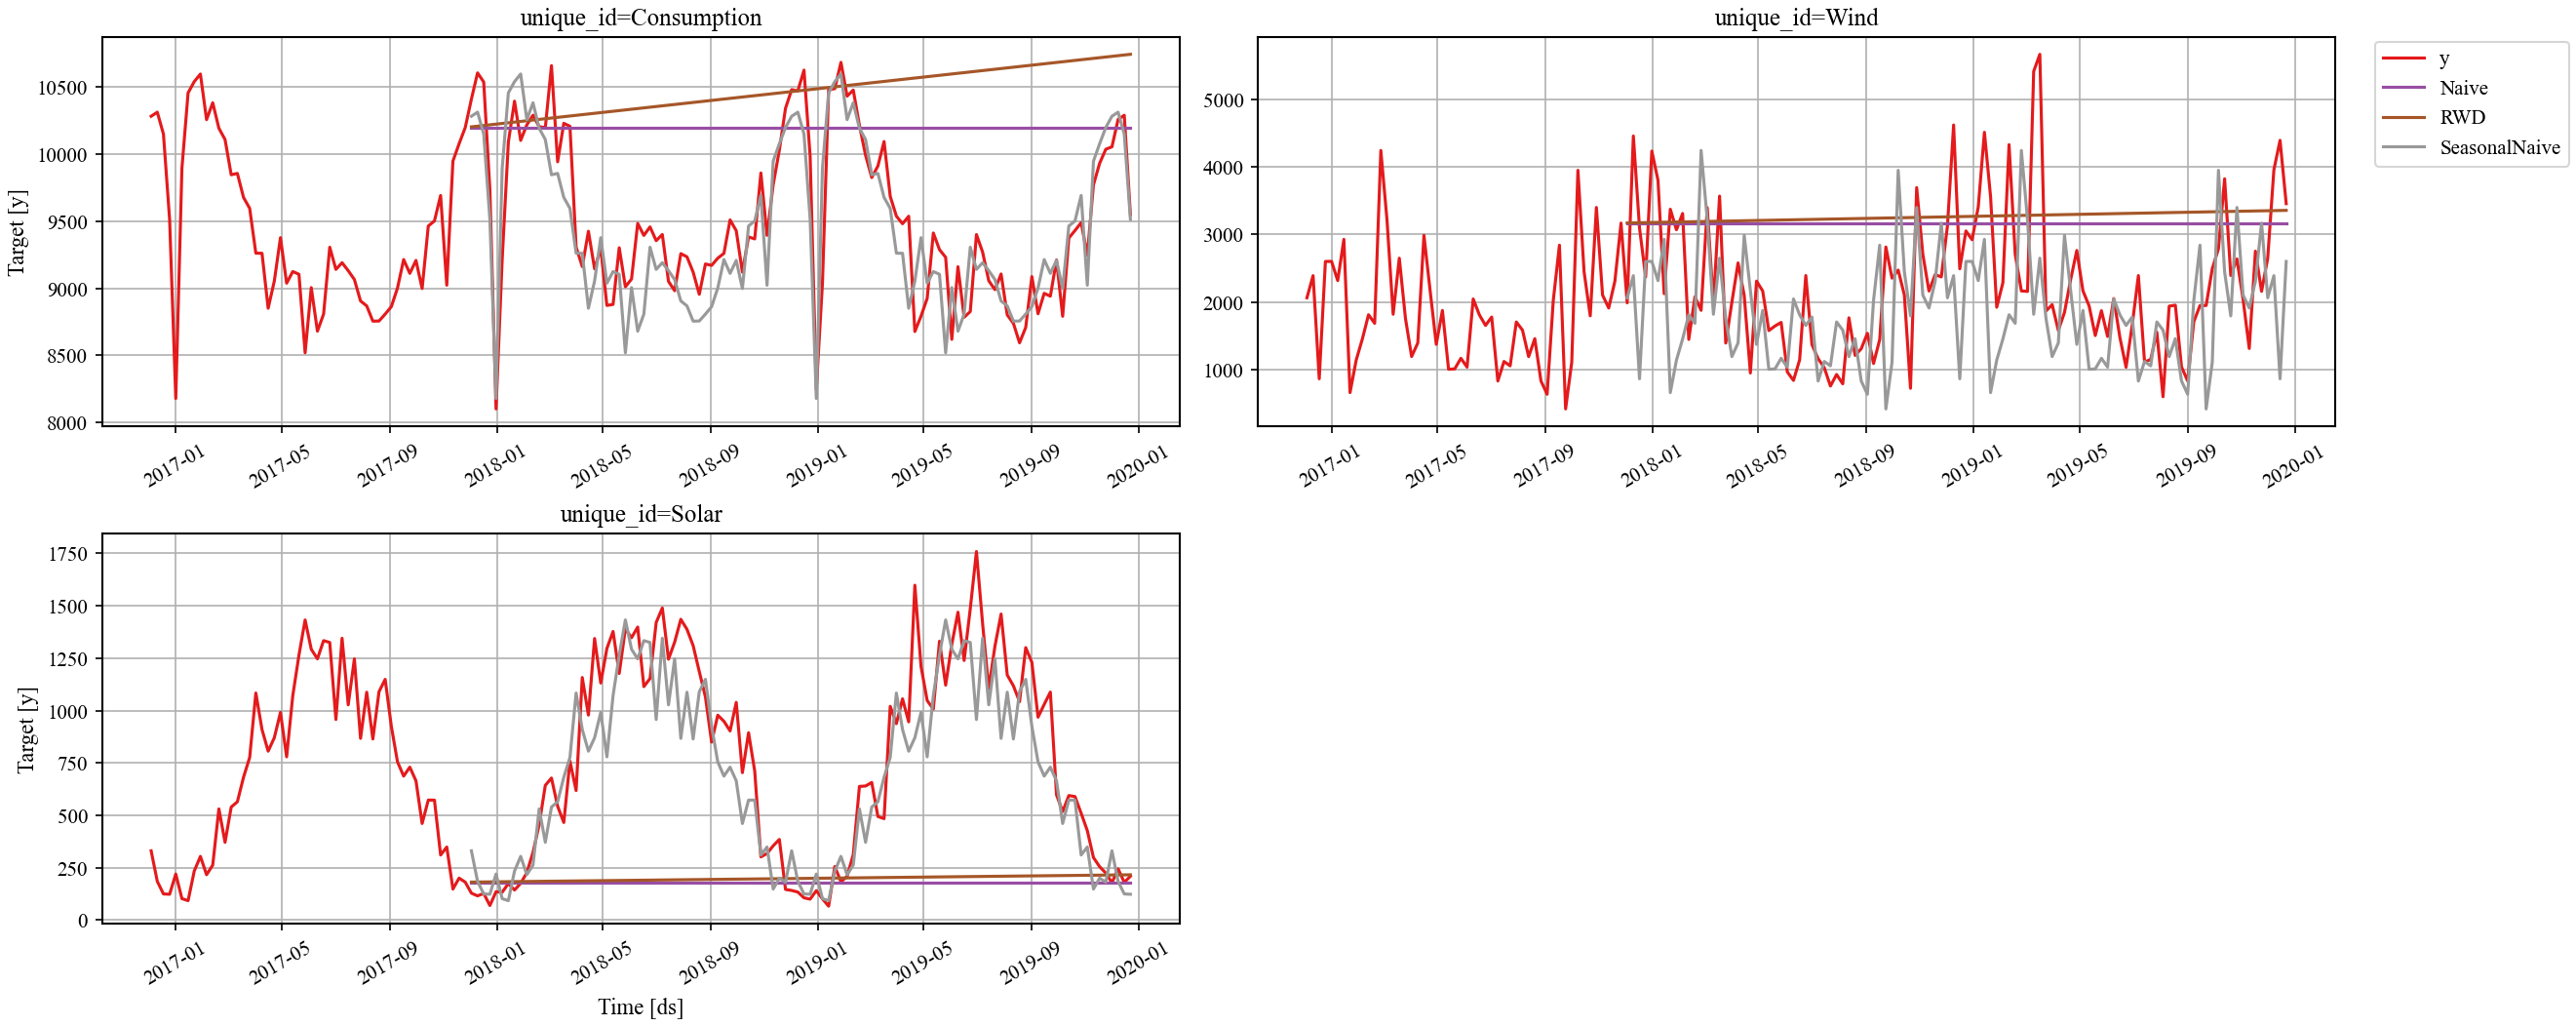

In [22]:
plot_series(df_train, 
            eval_base,#.rename(columns = {'y':'gt'}), 
            max_insample_length=SEASON,  
            palette='Set1')

#### Точечные оценки точности

Для оценка качества прогнозов будем использовать несколько типичных метрик [проверки ошибок предсказания](https://otexts.com/fpp3/accuracy.html). 
- В качестве базовой метрики воспользуемся [симметричной средней процентной ошибкой](https://mlpills.dev/time-series/error-metrics-for-time-series-forecasting/) (<b>Symmetric Mean Absolute Percentage Error, [sMAPE](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.performance_metrics.forecasting.MeanAbsolutePercentageError.html)</b>)
$$ sMAPE =2\frac{1}{H}\sum_{i=1}^{H} \frac{|y(h_i) − \hat{y}(h_i)|}{|y(h_i)| + |\hat{y}(h_i)|}
 $$

- `MASE` (Mean Absolute Scaled Error): качество модели по сравнению с наивной моделью независимо от масштаба ряда (< 1.0 = beats baseline, = 1.0 = matches baseline, > 1.0 = worse than baseline)
```MASE = 1 - mae(y_pred_complex, y_test)/mae(y_pred_naive, y_test)```

- `RMSE` (Root Mean Squared Error): — среднеквадратичная ошибка, подчёркивает большие выбросы

Для метрики `MASE` [необходимо также задать аргумент `seasonality`](https://nixtlaverse.nixtla.io/utilsforecast/index.html#evaluating). Задаим аргумент путем использования специальной функции `partial`. Это связано с тем, что в `Nixtla` модель сравнивает прогнозы с сезонной наивной моделью.

In [23]:
from functools import partial
season_mase = partial(mase, seasonality=SEASON)
metrics = [season_mase,  rmse, smape]


Для оценки метрик используем функцию `evaluate` как показано ниже

In [24]:
metrics_base = evaluate(
    df=eval_base,
    train_df=df_train,
    metrics=metrics,
).set_index('metric')

metrics_base

 

,unique_id,Naive,RWD,SeasonalNaive
metric,,,,
mase,Consumption,3.694171,4.782313,1.133374
mase,Solar,4.629018,4.530104,1.257398
mase,Wind,1.552464,1.634658,1.191797
rmse,Consumption,897.761521,1148.473111,304.600058
rmse,Solar,761.160964,746.931240,225.988109
rmse,Wind,1373.668114,1438.226789,1206.190676
smape,Consumption,0.039212,0.049925,0.012362
smape,Solar,0.520208,0.500980,0.133956
smape,Wind,0.245153,0.253844,0.223454


Сделаем не много другой вид

In [25]:
df_long = metrics_base.reset_index()
df_melted = df_long.melt(
    id_vars=['metric', 'unique_id'],
    var_name='model',
    value_name='value'
)

df_final = df_melted.pivot_table(
    index='unique_id',
    columns=['metric', 'model'],
    values='value'
)
df_final

metric           mase                                 rmse               \
model           Naive       RWD SeasonalNaive        Naive          RWD   
unique_id                                                                 
Consumption  3.694171  4.782313      1.133374   897.761521  1148.473111   
Solar        4.629018  4.530104      1.257398   761.160964   746.931240   
Wind         1.552464  1.634658      1.191797  1373.668114  1438.226789   

metric                        smape                          
model       SeasonalNaive     Naive       RWD SeasonalNaive  
unique_id                                                    
Consumption    304.600058  0.039212  0.049925      0.012362  
Solar          225.988109  0.520208  0.500980      0.133956  
Wind          1206.190676  0.245153  0.253844      0.223454

приемущества SeasonalNaive по всем показателям видны.

## Модель скользящего среднего

### Простое скользящее среднее (Simple Exponential Smoothing, SES)

Одними из наиболее простых методов являются семейство методов на основе экспоненциального сглаживания   (`Exponential Smoothing`, `Holt-Winter` и другие). Давайте посмотрим на их работу. Для начала оценим точность наиболее простого варианта `Simple Exponential Smoothing`.

SES  учитывает только прошлые значения с затухающими весами.
Чем ближе к настоящему, тем больше вес.
Используется, чтобы сгладить шум и получить простую модель уровня ряда, которая тоже служит базой для сравнения с более сложными методами.

Напомним, что простое экспоненциальное сглажевание выполняет тот же расчет взвешенного скользящего среднего (метод pandas <tt>.ewm()</tt>):<br>
$\begin{align}y_0 &= x_0 \\
y_t &= (1 - \alpha) y_{t-1} + \alpha x_t,\end{align}$

Чем α ближе к 1, тем прогноз быстрее реагирует на новые данные (меньше сглаживания)
Чем α ближе к 0, тем прогноз более «плавный», ориентирован на долгосрочный уровень ряда

коэффициент может быть выбран и автоматически


Рассмотрим несколько моделей `SimpleExponentialSmoothing`  с разными коэффициентами сглаживания `alpha`

In [26]:
from statsforecast.models import SimpleExponentialSmoothing, SimpleExponentialSmoothingOptimized

models = [SimpleExponentialSmoothing(alpha=0.01, alias="SES01"),
          SimpleExponentialSmoothing(alpha=0.5,alias="SES05"),
          SimpleExponentialSmoothing(alpha=0.8,alias="SES08"),
          SimpleExponentialSmoothingOptimized()]


In [27]:
sf = StatsForecast(
    models=models,
    fallback_model = SeasonalNaive(season_length=SEASON),
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, h = FH)

# out-of-sample forecast
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])
eval_sf.head(2)


,unique_id,ds,y,SES01,SES05,SES08,SESOpt
0,Consumption,2017-12-03,10409.045,9345.005342,10021.329549,10161.668177,10178.922835
1,Consumption,2017-12-10,10604.489,9345.005342,10021.329549,10161.668177,10178.922835


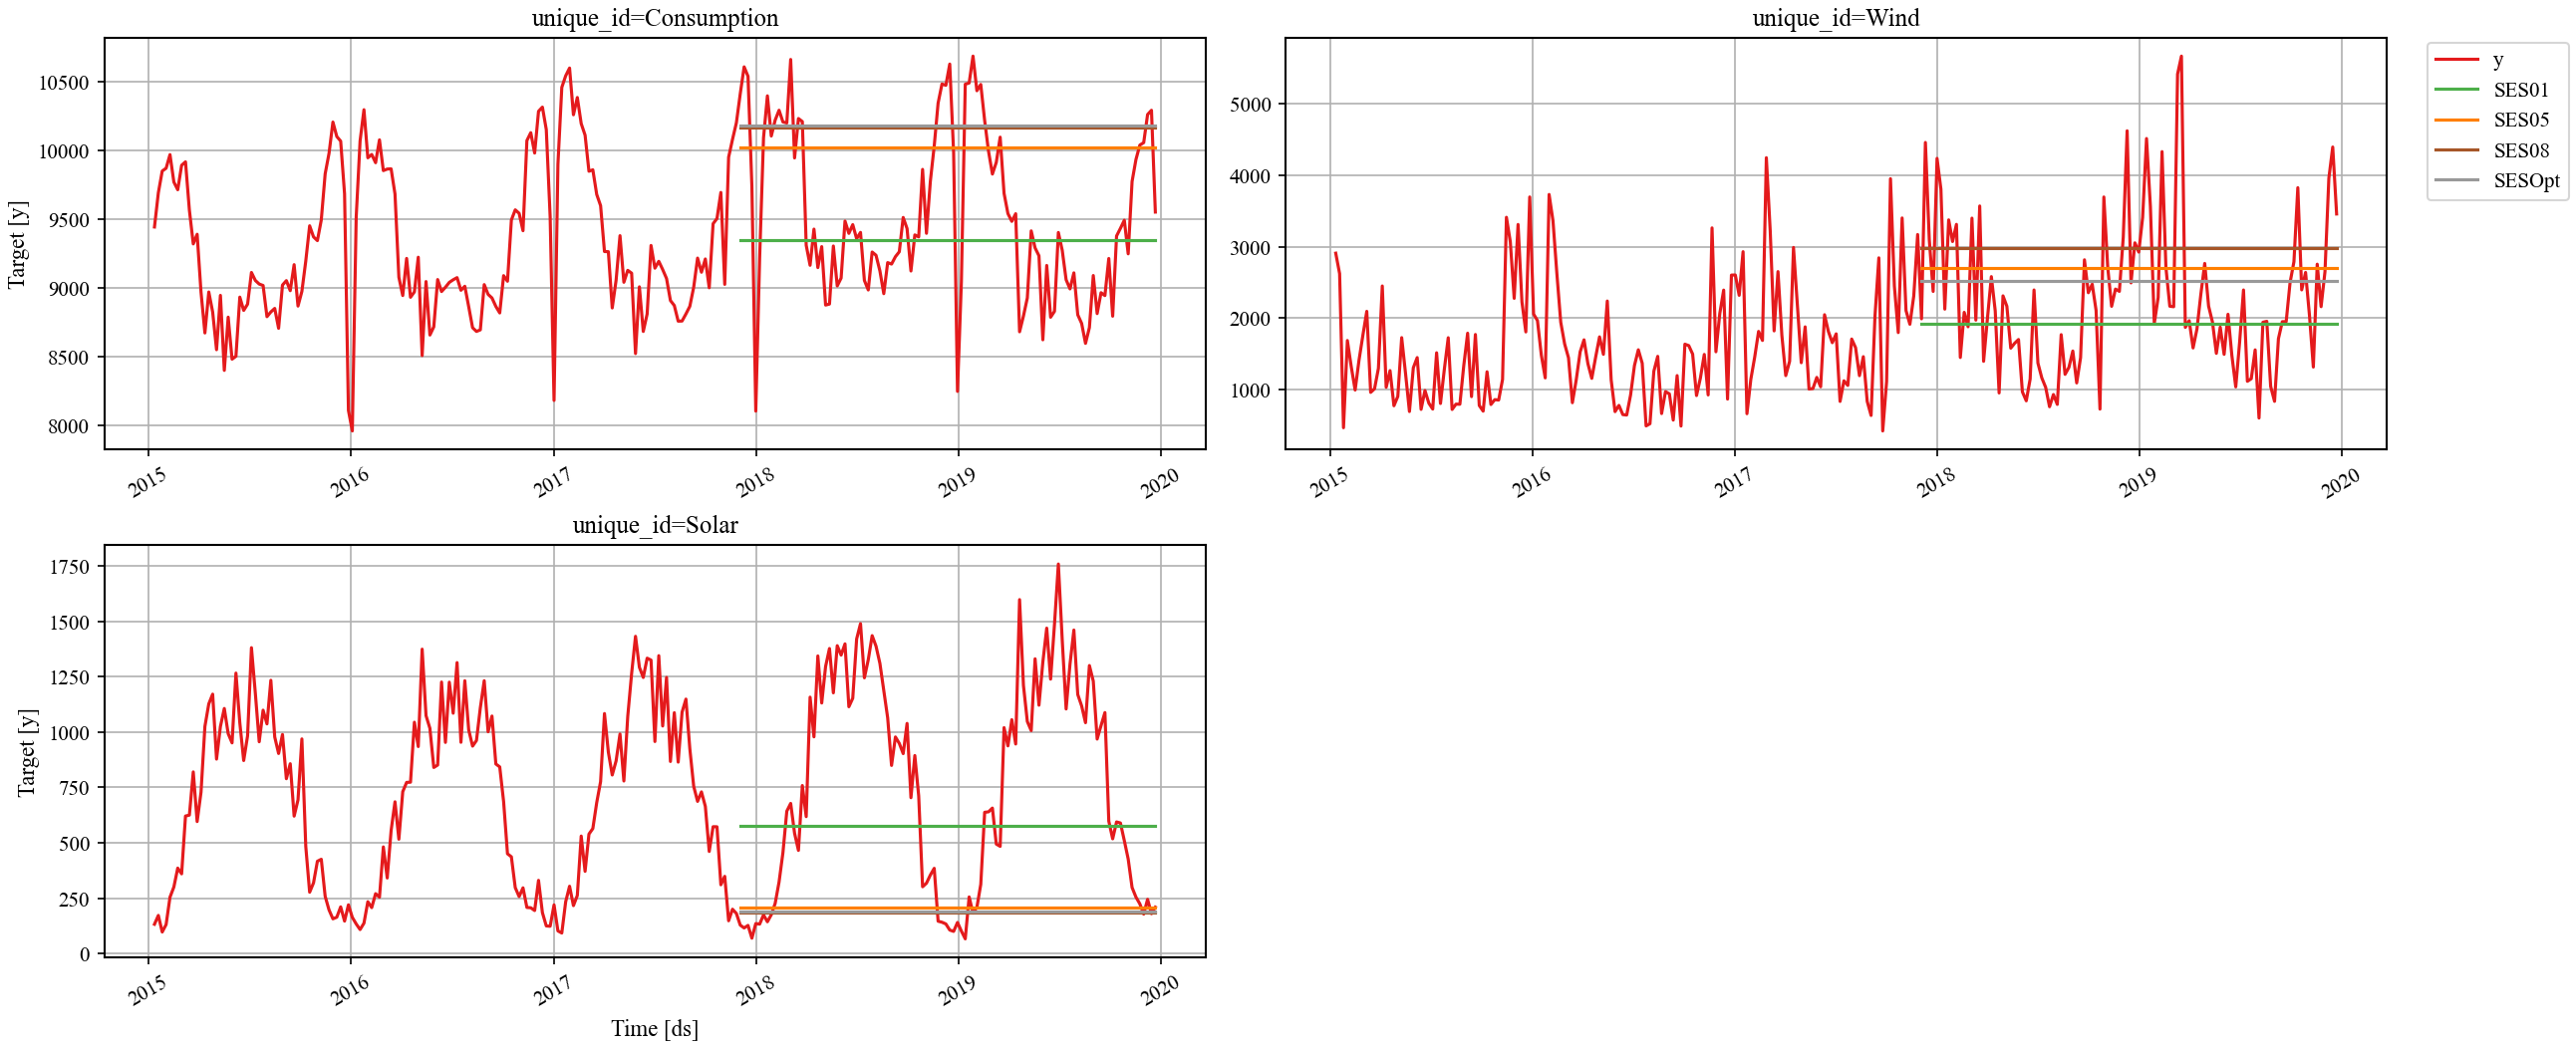

In [28]:
plot_series(
    df_train,
    forecasts_df = eval_sf,
    palette='Set1',
)

Видно, что модели дают результат похожий на навиное предсказание. Это происходит по тому, что модель в будущих предсказниях базируется на текущих значениях (`forecast(h=FH)` — это по сути `multi-step` forecasting для простых моделей). То есть  модель `SimpleExponentialSmoothing` вырождается при горизонте прогноза больше чем 1 шаг. 


### in-sample prediction

Проверим то как модель работает с наличием реальных данных, постров комибнацию: 
- __In-sample-prediction__   - задача когда предполагается, что данные постоянно пополняются и мы получаем новый прогноз на основе реальных наблюдений
- __Out-of-sample-forecasting__  - задача предсказания новых и неизвестных данных, по сути все будущие предсказания опираются на последние имеющиеся данные. Как правило тут чем дальше от последнего наблюдения, тем меньше точность.

In [29]:
fcst_sf = sf.forecast(df=df_train, h = FH, fitted=True)

# out-of-sample forecast
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])
eval_sf.head(2)

# in-sample forecast (FITTED = TRUE)
in_sample_sf = sf.forecast_fitted_values()

all_forecasts = pd.concat([in_sample_sf,eval_sf], ignore_index=True)
all_forecasts = all_forecasts.sort_values(['unique_id', 'ds']).reset_index(drop=True)
all_forecasts.head(2)

,unique_id,ds,y,SES01,SES05,SES08,SESOpt
0,Consumption,2015-01-11,9440.105,NaN,NaN,NaN,NaN
1,Consumption,2015-01-18,9689.010,9440.105,9440.105,9440.105,9440.105


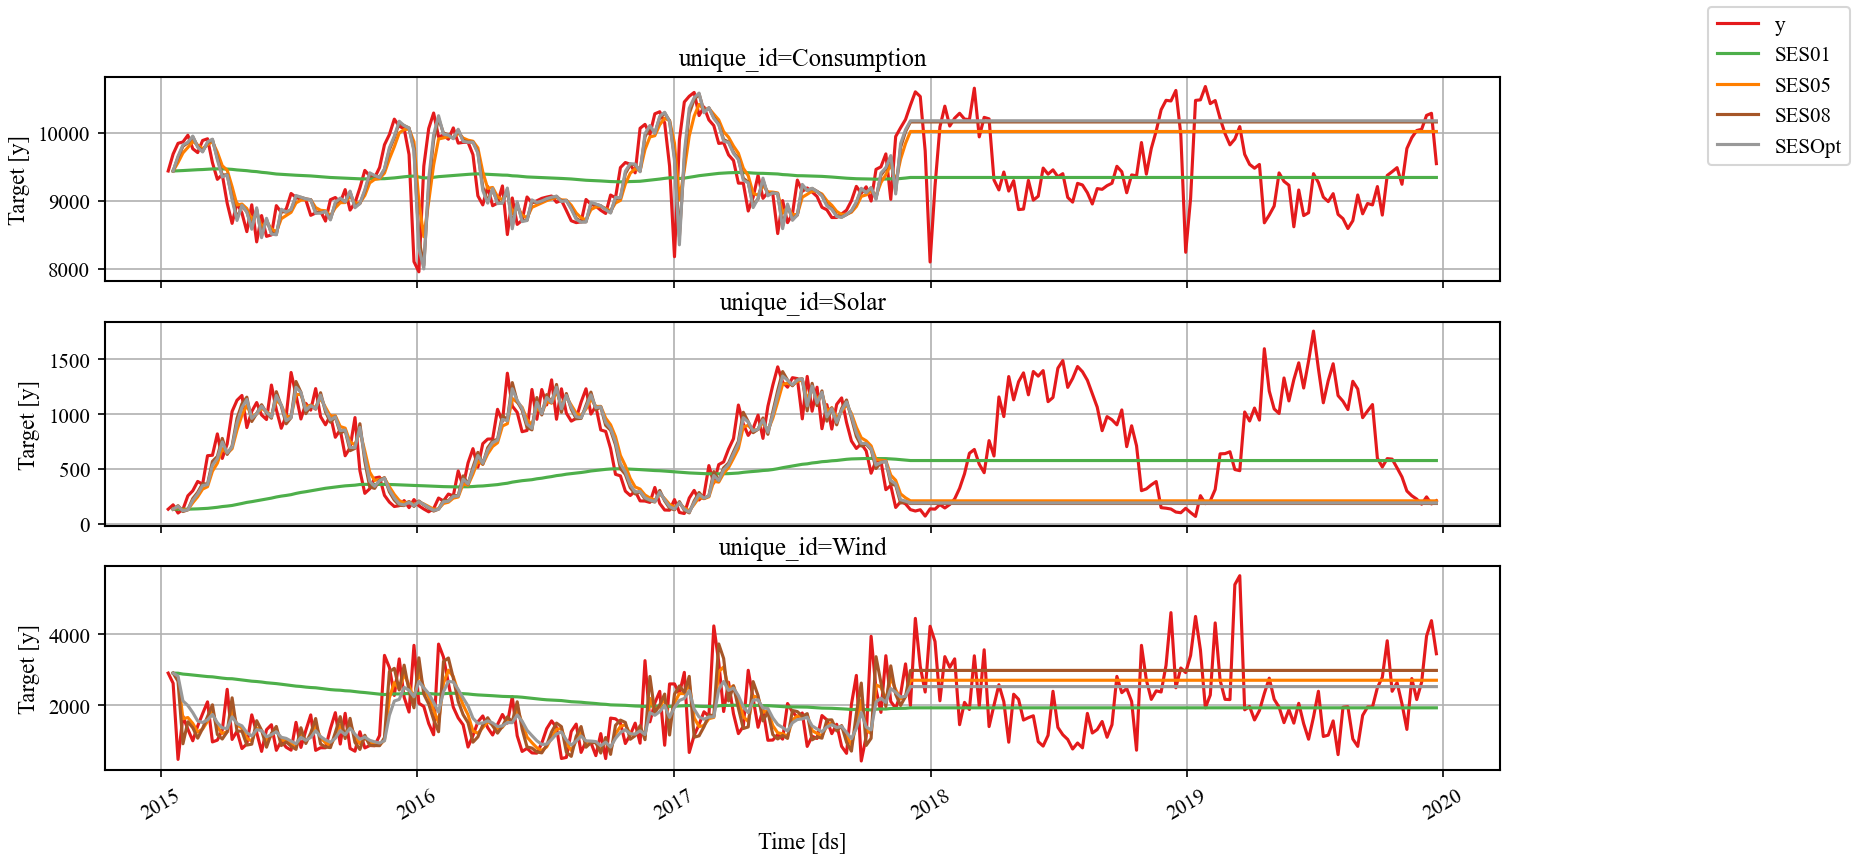

In [30]:
# # сколько уникальных рядов
n_rows = all_forecasts['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(
    # df_train,
    forecasts_df = all_forecasts,
    ax=ax,
    palette='Set1',
)

Видно, что модели с досточно большим коэффициентом `alpha` воспроизводят результат в режиме `one-step-ahead` достаточно хорошо.

### one-step-ahead forecasting

Смоделируем режим one-step-ahead для задачи предсказания.

In [31]:
from copy import deepcopy

# создаём пустой DataFrame для прогнозов
one_step_forecasts = []

df_hist = df_train.copy()

for t in range(FH):  # каждый шаг горизонта
    # делаем forecast на 1 шаг
    fcst = sf.forecast(df=df_hist, h=1)
    
    # добавляем в список
    one_step_forecasts.append(fcst)
    
    # подставляем реальные значения из df_test
    next_real = df_test[df_test['ds'] == fcst['ds'].iloc[0]]
    df_hist = pd.concat([df_hist, next_real], ignore_index=True)
fcst_one_step = pd.concat(one_step_forecasts, ignore_index=True)

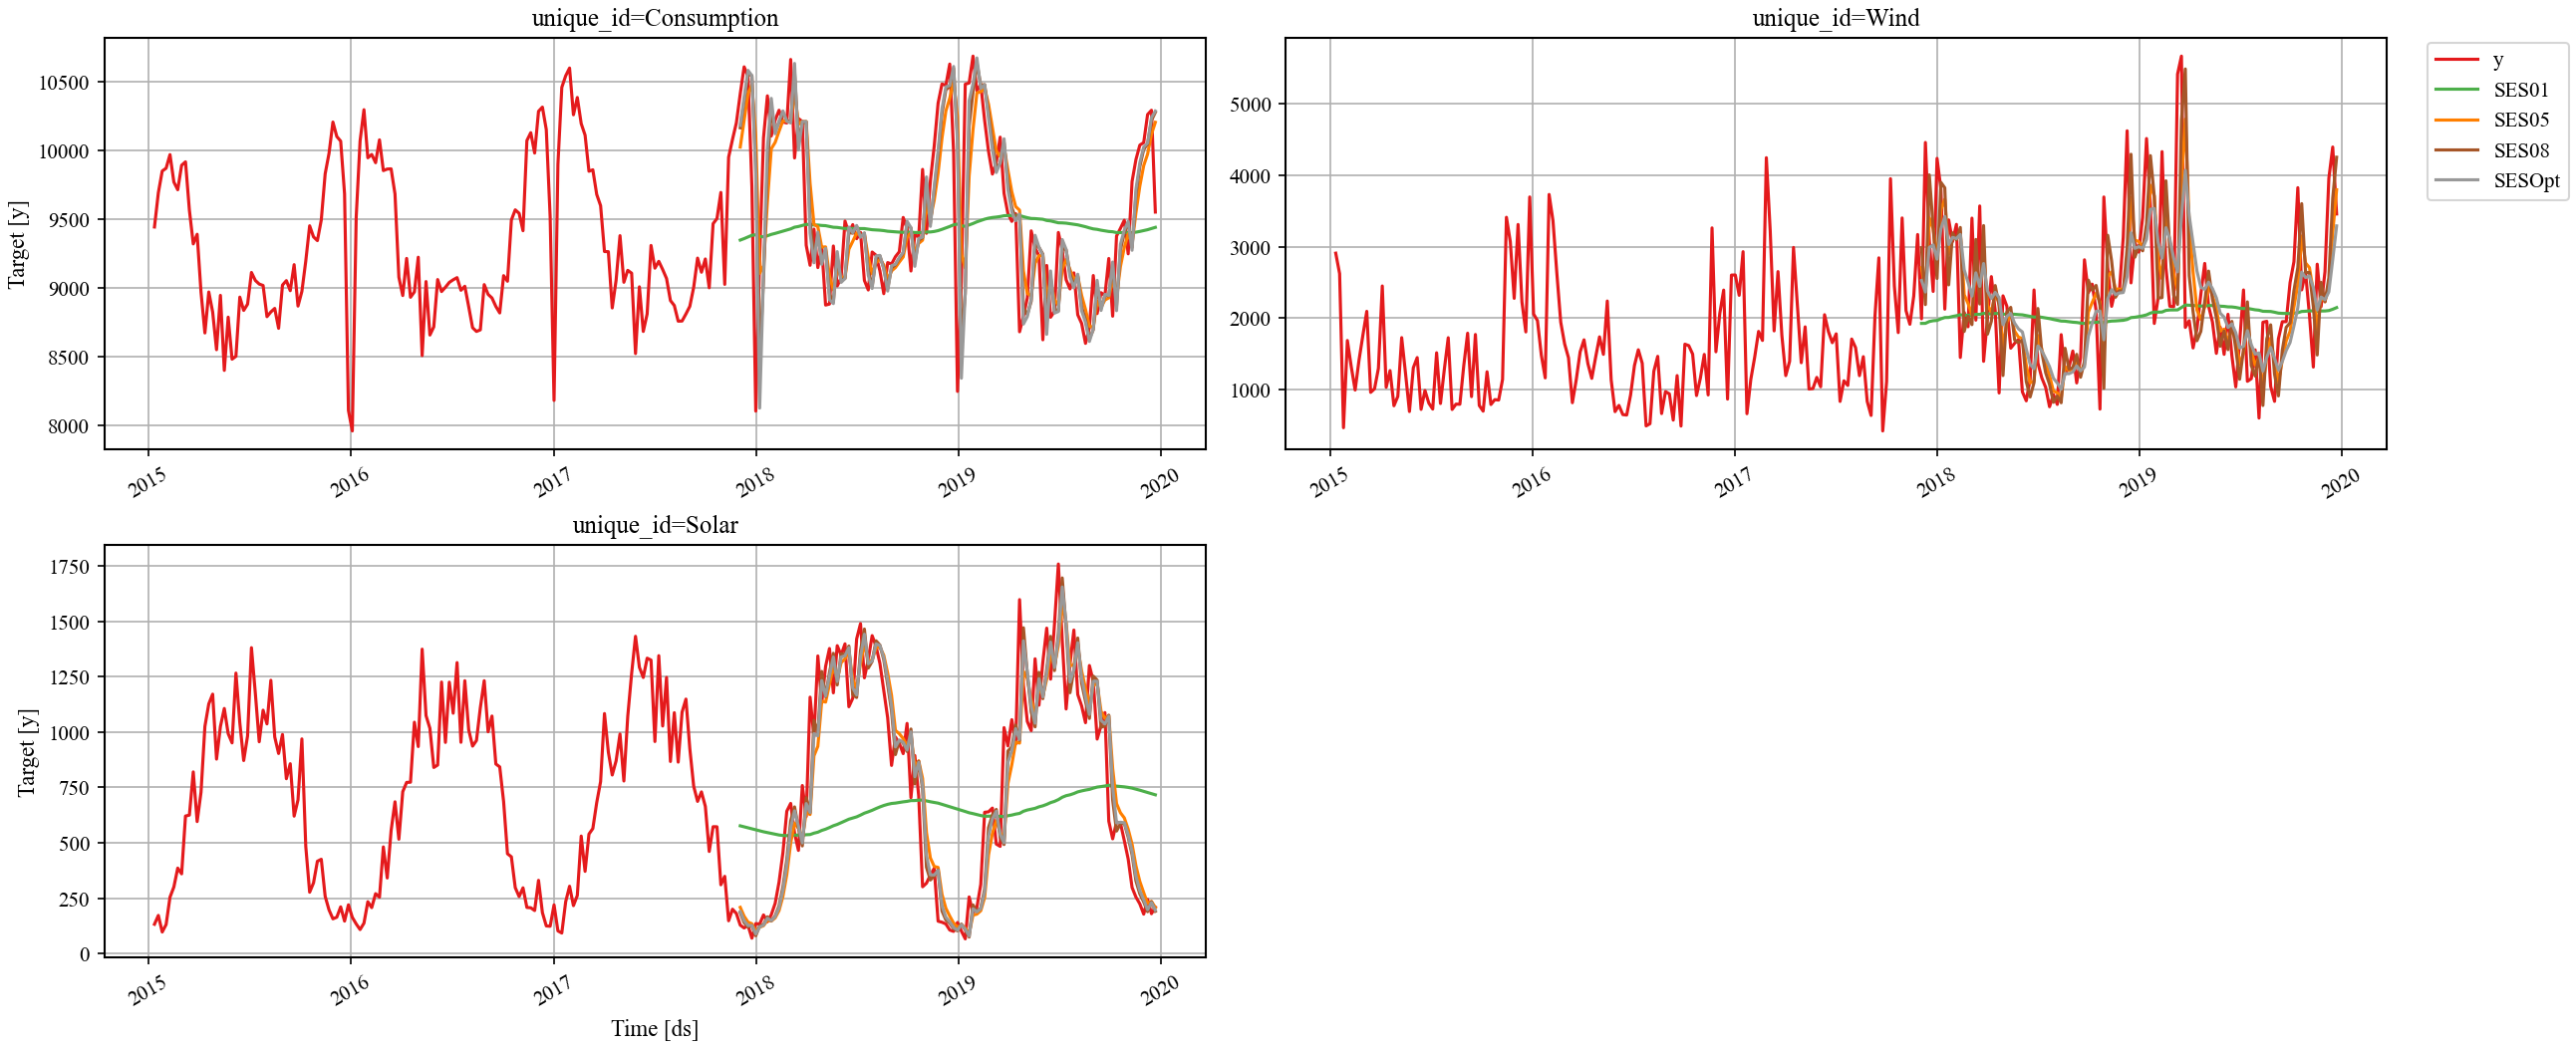

In [32]:
eval_sf = df_test.merge(fcst_one_step, on=['unique_id', 'ds'])
eval_sf.head(2)

plot_series(
    df_train,
    eval_sf,
    palette='Set1',
)

Действительно такой режим работает. Однако на практике это не всегда эффективно.

Убедится в этом можно увеличив горизонт предсказания.

### Сезонное экспоненциальное сглаживания

Помимо простого экспоненциального сглаживания Nixtla также предлагает метод сезонного экспоненциального сглаживания. По существу это метод, строящий прогноз для каждой точки сезона с шагом соотвественно в сезон методом SES. Метод SeasonalExponentialSmoothingOptimized также позволяет автоматически подобрать отпимальный коэффициент сглаживания.




In [33]:
from statsforecast.models import SeasonalExponentialSmoothing, SeasonalExponentialSmoothingOptimized

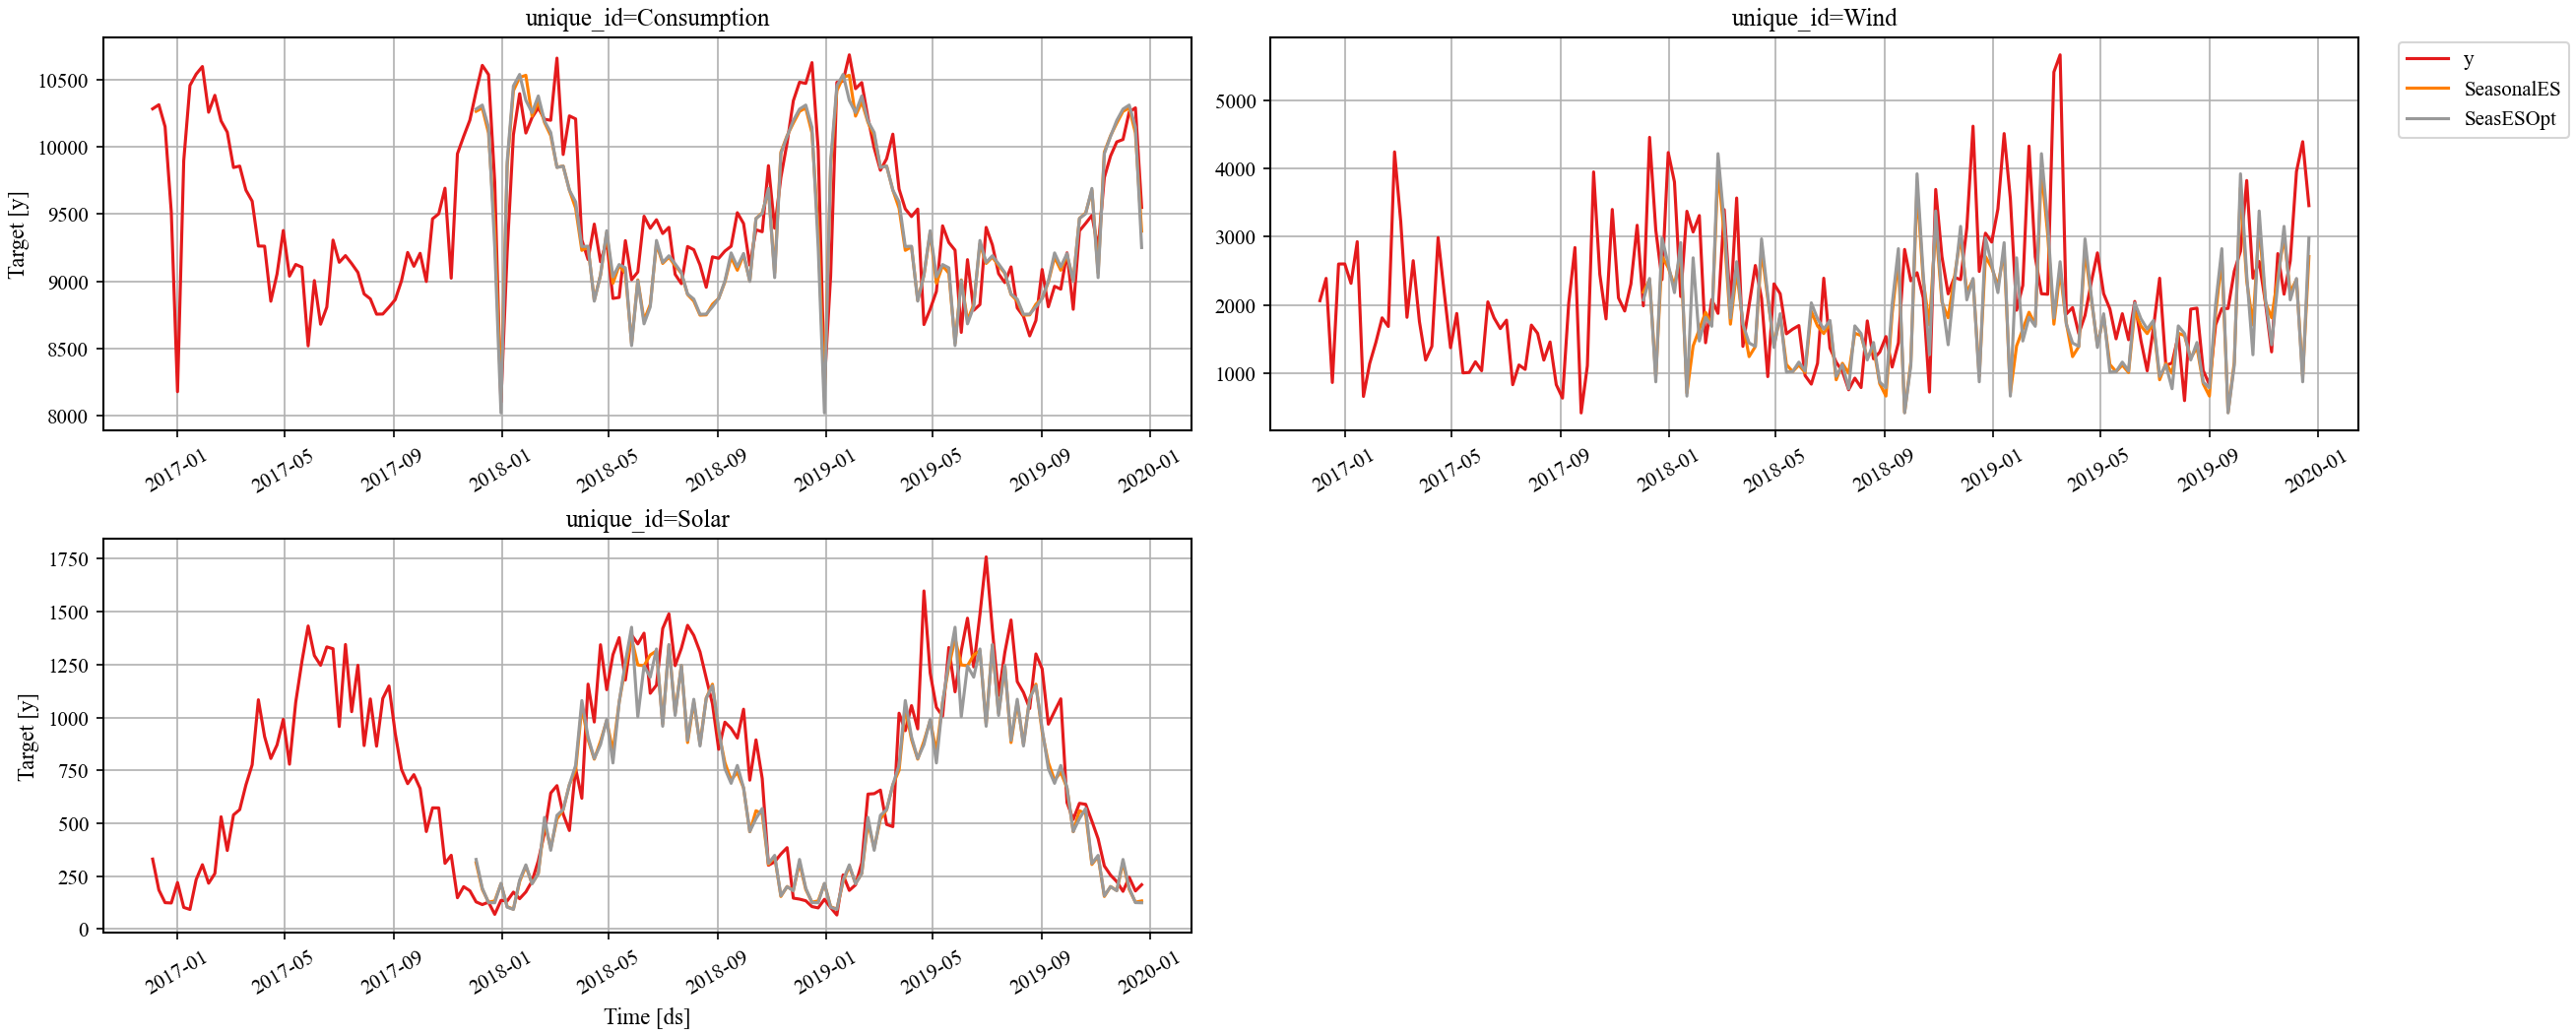

In [34]:
models = [SeasonalExponentialSmoothing(season_length = SEASON, alpha = 0.9),
         SeasonalExponentialSmoothingOptimized(season_length = SEASON)]

sf = StatsForecast(
    models=models,
    fallback_model = SeasonalNaive(season_length=SEASON),
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, h=FH)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

plot_series(df_train, eval_sf, max_insample_length=SEASON, palette='Set1')

#### Упражнения:
1. предлагается провести анализ метрик и визуальную оценку качества предсказания для моделей SES  в n-step-ahead режиме по сравнению с наивным предсказанием и сезонным SES.

### Theta-метод

[Theta-метод](https://nixtlaverse.nixtla.io/statsforecast/docs/models/autotheta.html) является расширением  метода экспоненциального сглаживания (SES). Theta-метод получил своё название от того, что использует две "тета"-линии, полученные из  второй численной производной исходного ряда метода экспоненциального сглаживания. таким образом Theta-метод разлагает временной ряд на долгосрочный тренд и локальную (SES) компоненту, позволяя моделировать и краткосрочные колебания. Метод особенно эффективен на данных с явно выраженным трендом, но без сильной сезонности. 

В качестве реализации метода будем использовать функцию `AutoTheta` которая позволяет:
- Автоматически определять наличие тренда и его тип (линейный, квадратичный, затуахющий),
- Учитывать сезонность (если она указана) путем ее декомпозии (напр. вычитания),
- Производить авто-выбор нескольких вариантов модели Theta: (Standard, Optimized, Dynamic,)

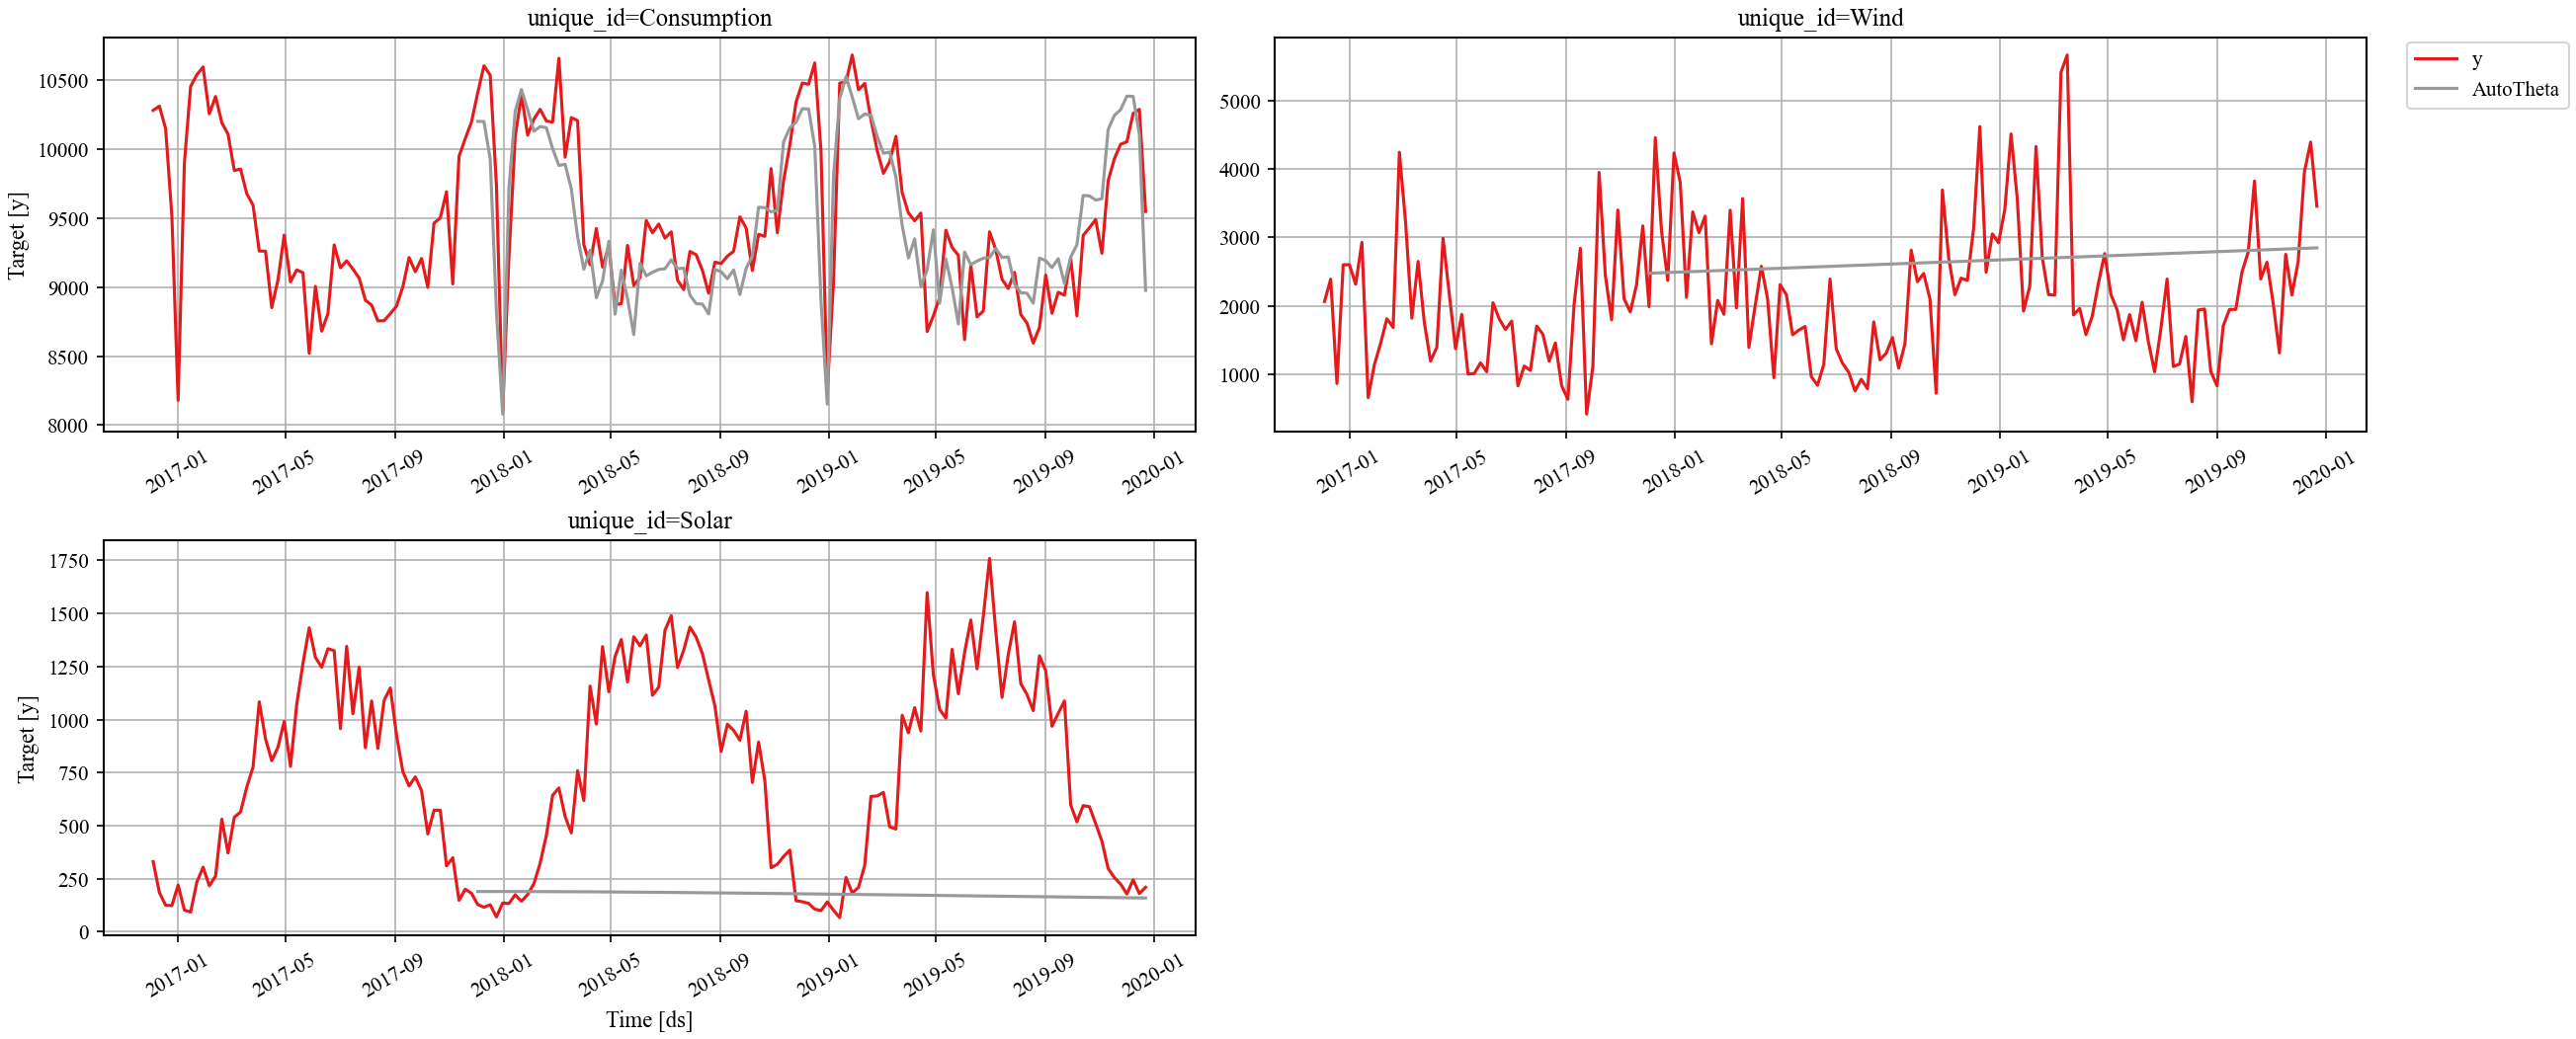

In [35]:
from statsforecast.models import AutoTheta

models = [AutoTheta(season_length=SEASON,
                    model = None, # 'STM','OTM', 'DSTM','DOTM'
                     decomposition_type="multiplicative")]
sf = StatsForecast(
    models=models,
    fallback_model = SeasonalNaive(season_length=SEASON),
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, h=FH)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

plot_series(df_train, eval_sf, max_insample_length=SEASON, palette='Set1')

In [36]:
metrics_base = evaluate(
    df=eval_sf,
    train_df=df_train,
    metrics=metrics,
)

metrics_base.reset_index().pivot(
    index='metric',
    columns='unique_id',
    values='AutoTheta')



unique_id,Consumption,Solar,Wind
metric,,,
mase,1.300816,4.665466,1.200480
rmse,338.251716,764.547749,1115.985697
smape,0.014119,0.529947,0.203781


Модель справилась с рядом `Consumption`, но для других ВР видимо не хватает данных

### Комплексная экспоненциальная модель CES

Другим примером [экспоненциальных моделей](https://openforecast.org/adam/exponential-smoothing.html) является комплексная экспоненциальная модель [CES](https://nixtlaverse.nixtla.io/statsforecast/docs/models/autoces.html). Этот подход позволяет рассмотреть модель как сумму линейного трнеда и сложного комплексного тренда (цикличности), которая бы включала в себя и сезонную составляющу. Для модели такого рода строится экспонециальное сглаживание. Модель реализуется также в пакете `Nixtla`.  


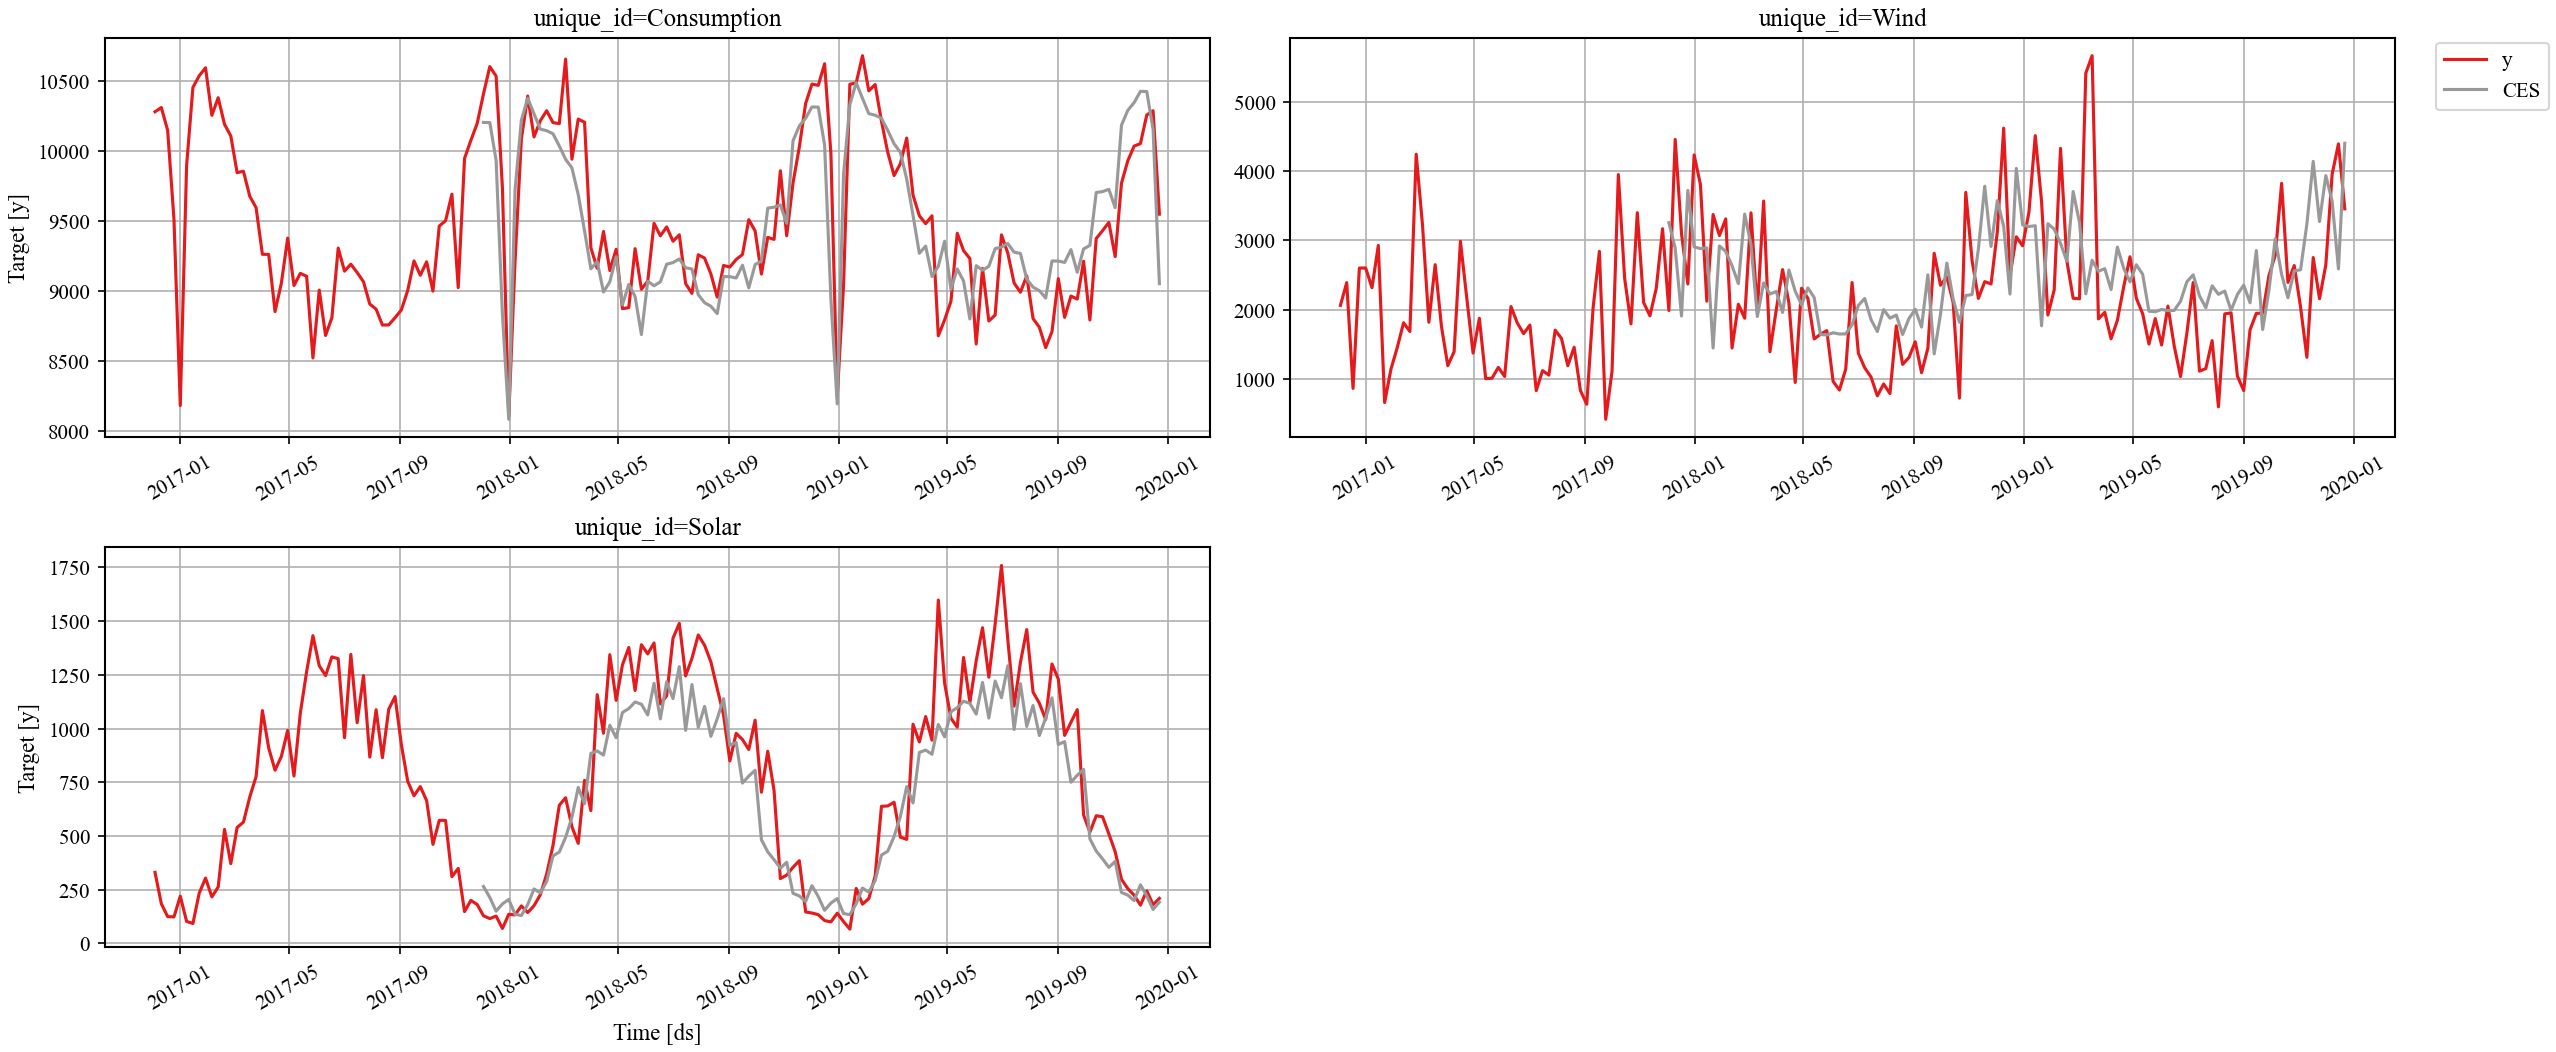

In [37]:
from statsforecast.models import AutoCES

models = [AutoCES(season_length=SEASON)]


sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, h=FH)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

plot_series(df_train, eval_sf, max_insample_length=SEASON, palette='Set1')

In [38]:
metrics_base = evaluate(
    df=eval_sf,
    train_df=df_train,
    metrics=metrics,
)

metrics_base.reset_index().pivot(
    index='metric',
    columns='unique_id',
    values='CES'
)

unique_id,Consumption,Solar,Wind
metric,,,
mase,1.274771,1.163049,1.039044
rmse,330.076506,196.666284,995.737953
smape,0.013813,0.125050,0.177053


#### Упражнения: 
Сравнить поведение `Theta`, `CES` и  сезонной наивной модели.

### Другие методы экспоненциального сглаживания



#### Методы Холта и Холта-Винтерса

На самом деле методы экспоненциального сглаживания представляют собой достаточно ширкое семейство методов для простого и надежного моделирования ВР. В наиболее простом случае среди таких методов следует указать:

- [Метод Холта](https://nixtlaverse.nixtla.io/statsforecast/docs/models/holt.html) представляет собой продвинутый аналог SES для многошагового предсказания ВР с явным трендом. Метод по существу раскладыавет ВР на тренд и сезонность. Разложение может быть мультипликативным или аддитивным.
- [Метод Холта-Винтерса](https://nixtlaverse.nixtla.io/statsforecast/docs/models/holtwinters.html) -  представляет собой расширение метода Холта на ВР с явновыраженной простой сезонность. По сути метод строит скользящее среднее как по тренду, так и по каждой точки сезона (по сезонной составляющей ).

In [39]:
from statsforecast.models import Holt, HoltWinters

In [40]:
models = [Holt(season_length=SEASON, error_type="A", alias="Holt_Add"),
          HoltWinters(season_length=SEASON, error_type="A", alias="HW_Add"),
         ]

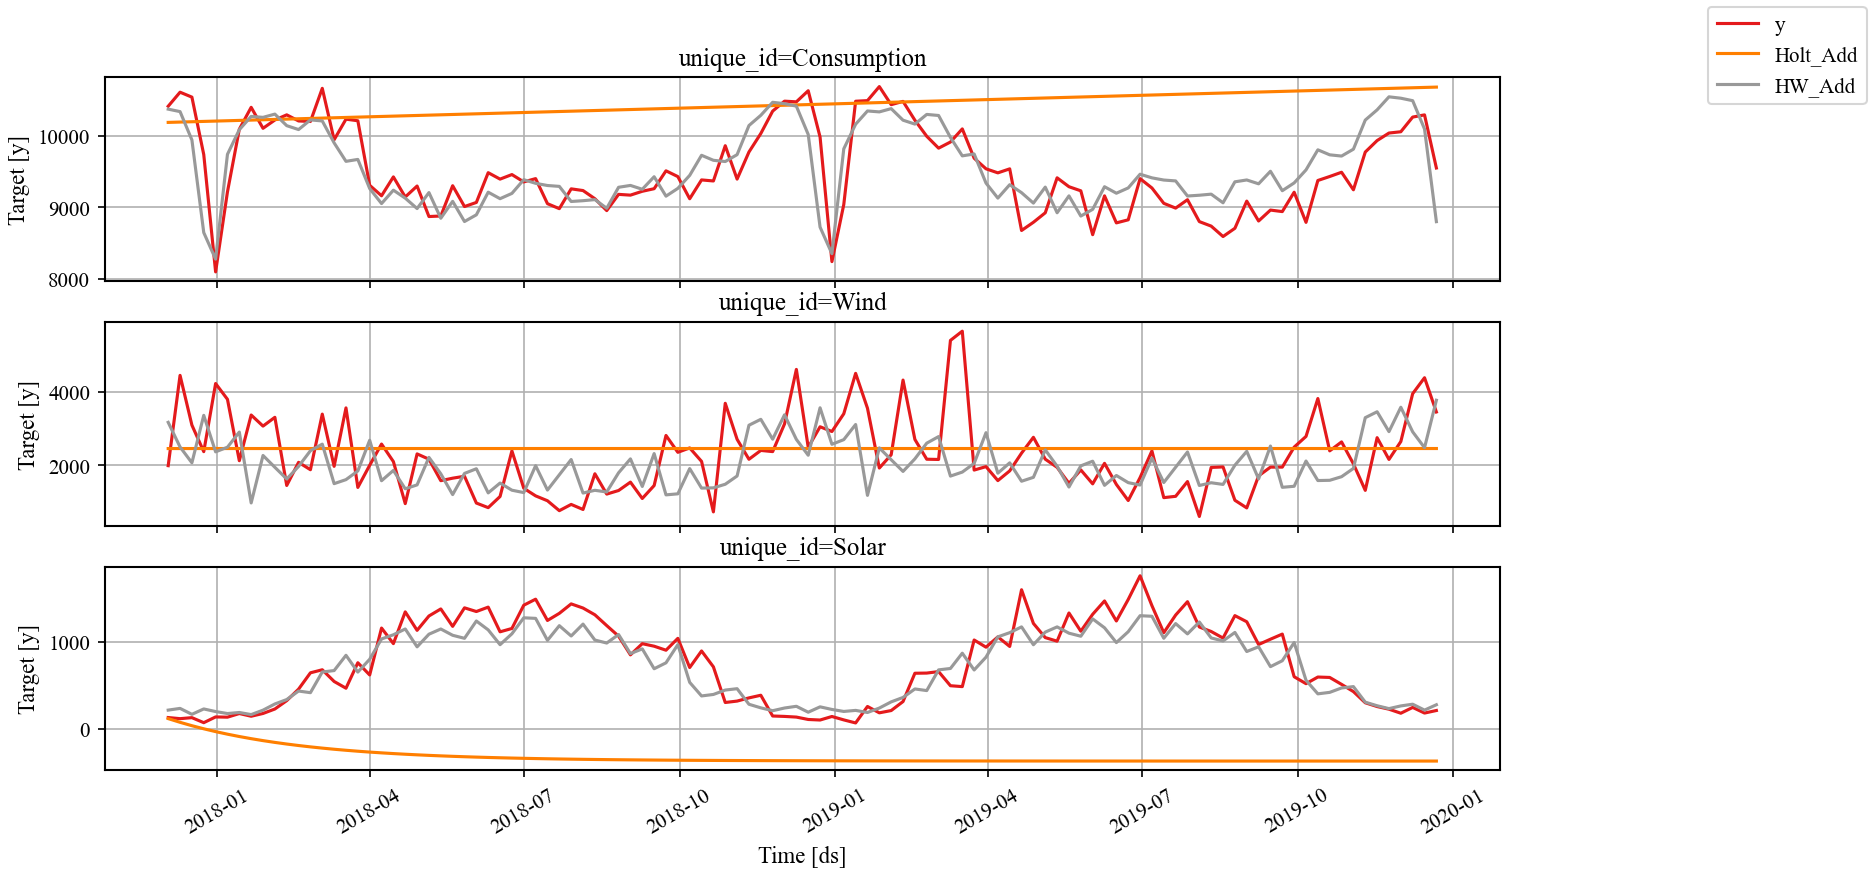

In [41]:
sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, h=FH)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

# # сколько уникальных рядов
n_rows = all_forecasts['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(
    # df_train,
    forecasts_df = eval_sf,
    ax=ax,
    palette='Set1',
    # linestile = ['--','-','-']
)

#### Методы Error-Trend-Seasonality

Обобщением и более продвинутым вариантом методов Холта-Винтерса яваляется метод  [`Error-Trend-Season (ETS)`](https://nixtlaverse.nixtla.io/statsforecast/docs/models/autoets.html). Метод позволяет позволяет автоматически оценивать параметры моделей экспоненциального сглаживания с трендом и сезонностью для случаев аддитивнго, мультипликативного или затухающего ВР. Частными примерами модели `ETS(ZZZ)` являются:
* Simple Exponential smoothing: `ETS(A,N,N)`.  
* Triple Exponential smoothing - Holts-Winters: `ETS(A,A,A)`. 
* и многие другие.

В `Nixtla` модели `AutoETS` сами выбирает оптимальную комбинацию компонентов и параметры, включая необходимость дополнительнго преобразования тренда (бокс-кокс). Однако данные модели требуют обозначения сезонности.  Использование таких моделей удобно для коротких или сложных рядов, где трудно заранее понять тренд. 

> Отметим, что методы <tt>Exponential smoothing</tt> использует эвристические значения для начальных состояний, а затем оценивает параметры сглаживания, оптимизируя функцию потерь `MSE`. В тоже время `ETS()` оценивает и начальные состояния, и параметры сглаживания, оптимизируя функцию максимального правдоподобия (`NNL`) (что эквивалентно оптимизации MSE только для линейных аддитивных моделей). \
> Однако в `Nixtla` <tt>Exponential smoothing</tt> реализуется именно как частные случаи `ETS`
> В ряде случаев можно также рассматривать и другие модели на основе экспоненциального сглаживания, например [с регрессией](https://orbit-ml.readthedocs.io/en/stable/tutorials/dlt.html) или с разделением [глобального и т.н. локального тренда](https://num.pyro.ai/en/stable/tutorials/time_series_forecasting.html).

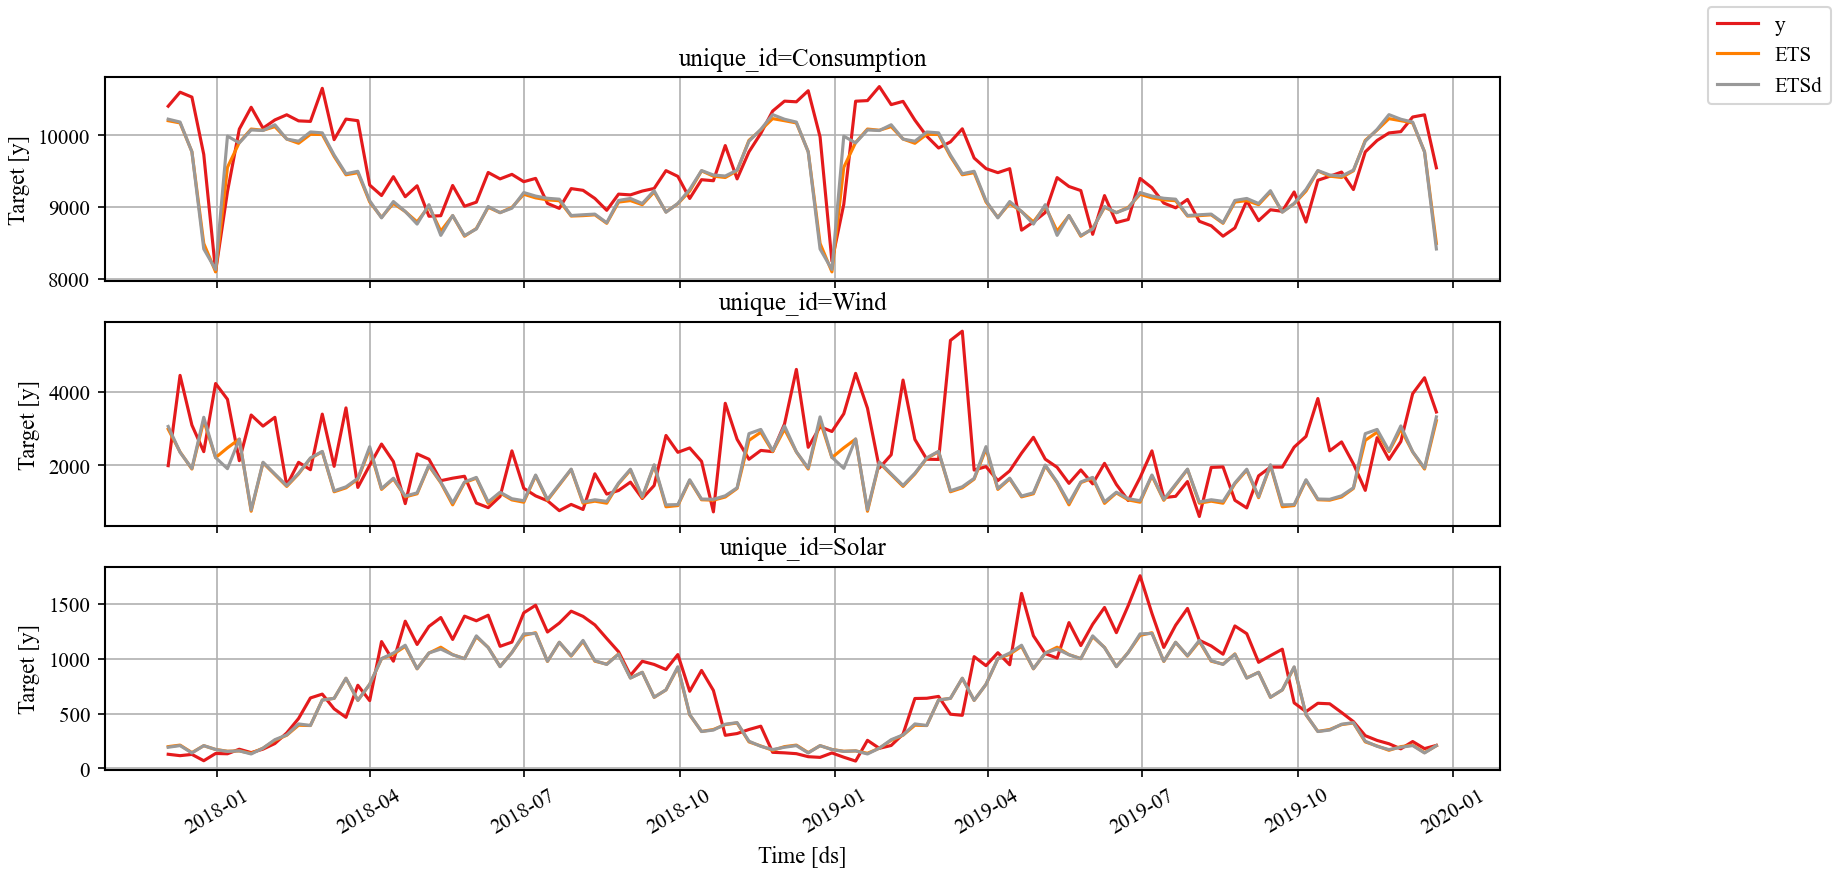

In [42]:
models = [
    AutoETS(season_length=SEASON, model='ZZA', damped = False, alias='ETS'),
    AutoETS(season_length=SEASON, model='ZZA', damped = True, phi=0.8, alias='ETSd'),
]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, h=FH)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

alias = [x for x in fcst_sf.columns if not x in base_cols]

n_rows = eval_sf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(
    # df_train,
    forecasts_df = eval_sf,
    ax=ax,
    palette='Set1',
)



In [43]:
metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
).pivot(
    index='metric',
    columns='unique_id',
    values=alias
)
metrics_sf_models

ETS                                 ETSd              \
unique_id Consumption       Solar         Wind Consumption       Solar   
metric                                                                   
mase         1.484139    1.251720     1.116494    1.529479    1.245685   
rmse       398.831799  212.830178  1211.199033  417.539339  212.128261   
smape        0.016131    0.128794     0.208739    0.016631    0.128146   

                        
unique_id         Wind  
metric                  
mase          1.127900  
rmse       1215.657855  
smape         0.208750

#### Упражнение
- Реализуйте в ETS модели SES, Holt, Holt-Winters.
- Сравните точности изученных моделей экспоненциального сглаживания.

## Использование декомпозиции ВР в задачах предсказания

### Декомпозиция STL from statsmodels

Одним из методов оценки данных с вилянием сезонности и тренда является использование предварительной декомпозиции  временного ряда. Одним из наиболее простых методов декомпозиции является разделение на тренд, сезонность и остаток.  Давайте посмотрим на то, как будут выглядеть результаты такого разложения.

]>* Отметим, что в наиболее простом случае разложить ВР $y(t)$ на составляющие можно бы было следующим алгоритмом 
>* Вычислить тренда $T(t)$, например методом скользящего среднего с длинным окном.
>* Вычислить функционала вида  $y(t)-T(t)$ (`Detrend`).
>* Вычислить основную сезонную составляющую $S(t)$ путем усреднение знечений с шагом сезонности `s`. Например, для месячных данных сезонный компонент для марта представляет собой среднее значение всех мартовских значений в данных без тренда. Этот шаг можно бы было проделать для каждого значения сезонности.  
>* Создать ряд сезонностей $S(t)$ заданной длительности.
>* Вычислить остаток разложения $R(t) =y(t)-T(t)-S(t)$
>
>Однако, такое разложение было бы не стабильным к нестационарностям,  редким событиям (в т.ч. аномалиям и регулярным событиям) и сложному виду тренда.
<!-- https://medium.com/analytics-vidhya/time-series-forecasting-using-tbats-model-ce8c429442a9
https://otexts.com/fpp2/classical-decomposition.html
https://www.openforecast.org/adam/classical-seasonal-decomposition.html
http://www.gardner.fyi/blog/STL-Part-II/ -->

Одним из наиболее популярных среди таковых является использование `STL` (<tt>Seasonal-Trend decomposition using LOESS </tt>) предсказания. Метод позволяет разложить ВР устойчиво к типичным выбросам и редким событиям. 

Метод STL заключается в использовании двух циклов:
* Вычисляется линейный тренд и удаляется из ряда.
1. Внутренний цикл (уточнение компонент):
    * вычисляется сезонная компонента (усреднение по сезонным окнам).
    * ряда вычитается сезонность, 
    * с помощью LOESS вычисляется тренд.
    * Считается остаток: исходные данные минус тренд и минус сезонность.
2. Внешний цикл (борьба с выбросами):
    * На основе остатков вычисляются веса: большие остатки (выбросы) получают маленькие веса.
    * Внутренний цикл повторяется, но теперь LOESS учитывает эти веса — выбросы почти не влияют на результат.
* Шаги 2–3 повторяются несколько раз, пока разложение не стабилизируется.


Канонический метод `STL` реализован в классической библиотеке [statsmodels](https://www.statsmodels.org/dev/examples/notebooks/generated/stl_decomposition.html). 
 
Пакет [`Nixtla`](https://nixtlaverse.nixtla.io/statsforecast/docs/models/multipleseasonaltrend.html) включает реализацию разложения методом мультисезонного STL, использующих разлжение ВР в целях предсказания.

Также отметим, что после аппроксимации разложения предсказатель для тренда [может быть заменен на альтернативными методами](https://www.statsmodels.org/dev/examples/notebooks/generated/stl_decomposition.html).


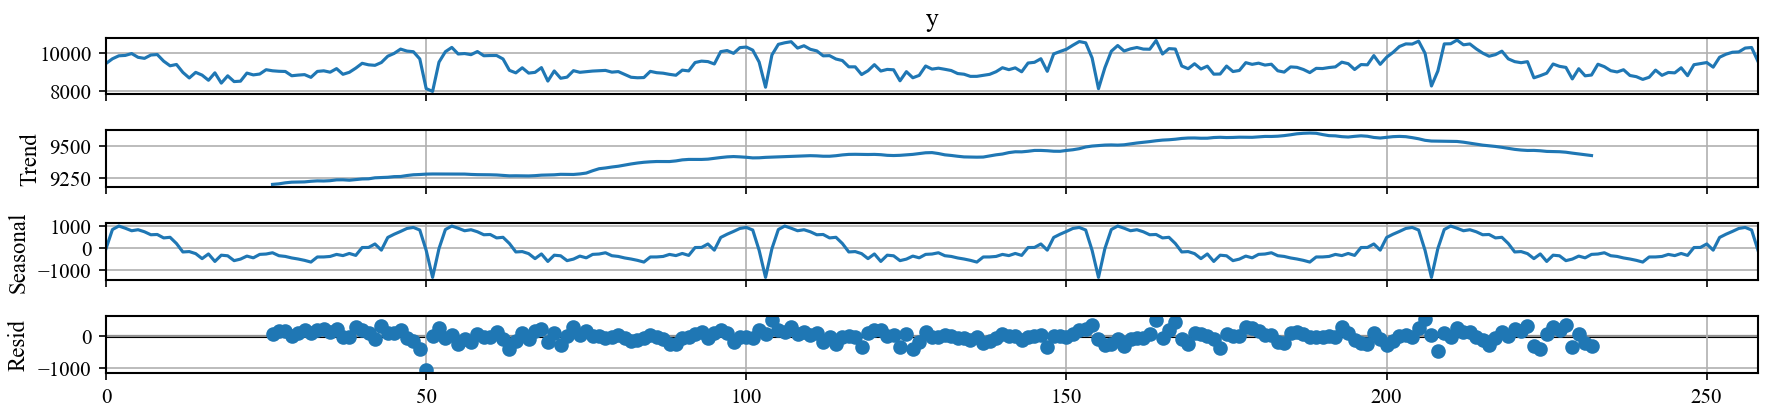

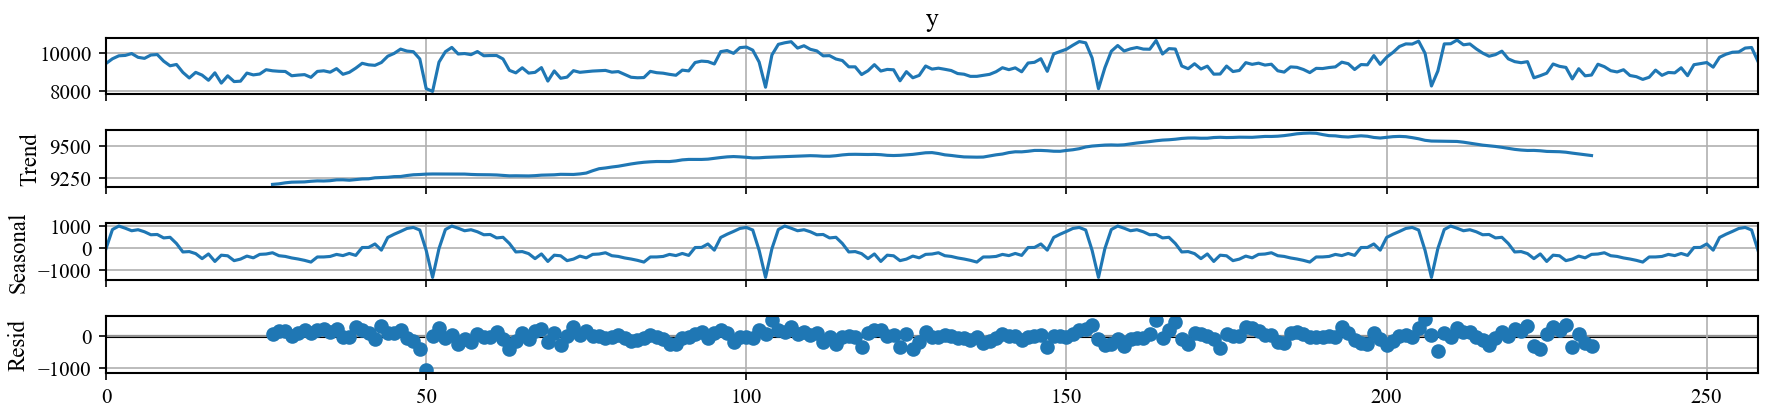

In [44]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
result = seasonal_decompose(panel_df[panel_df['unique_id'] == 'Consumption']['y'], model='additive', period = SEASON)
result.plot()

Построим процедуру STL для формата `panel_df`

In [45]:
def stl_decompose(group):
    group = group.sort_values('ds')
    res = STL(group['y'], period=SEASON, robust=True).fit()

    group['trend'] = res.trend
    group['seasonal'] = res.seasonal
    group['residual'] = res.resid
    return group

panel_df = panel_df.groupby('unique_id', group_keys=False,)[['unique_id','ds','y']].apply(stl_decompose)
panel_df.head(3)

,unique_id,ds,y,trend,seasonal,residual
0,Consumption,2015-01-11,9440.105,9182.943846,317.811586,-60.650432
1,Consumption,2015-01-18,9689.010,9185.275317,562.758168,-59.023485
2,Consumption,2015-01-25,9847.035,9187.595262,793.693948,-134.254210


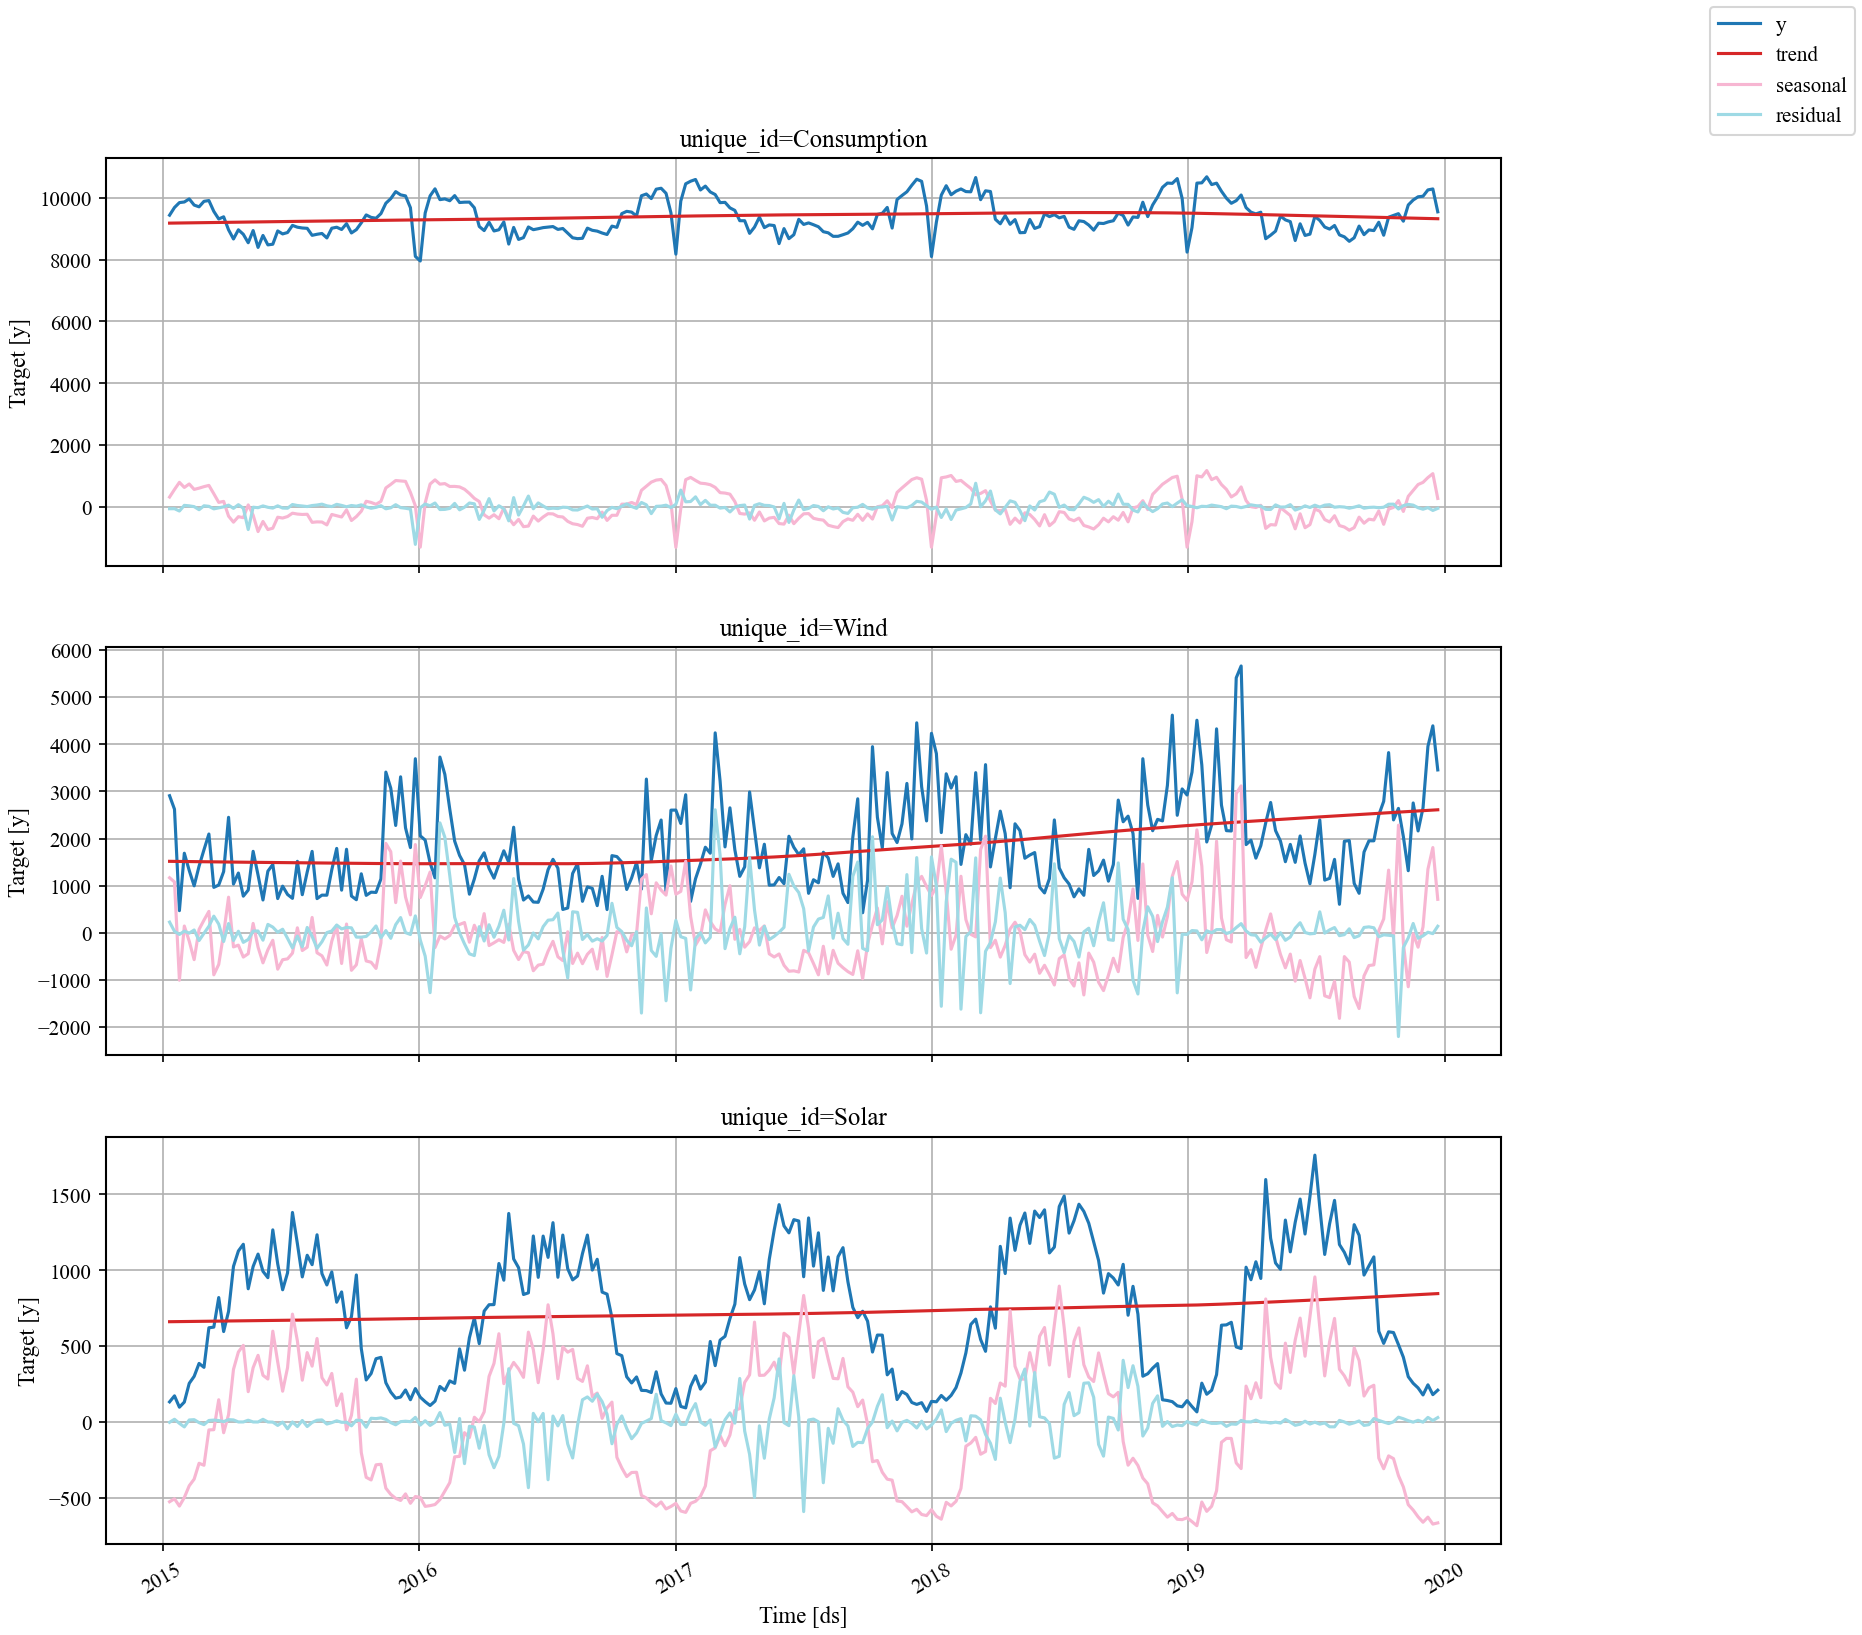

In [46]:
fig, ax = plt.subplots(3, 1, figsize=(12, 4*3), sharex=True)
plot_series(
    # df_train,
    forecasts_df = panel_df,
    ax=ax,
    palette='tab20',
)

In [47]:
df_test_stl  = panel_df.groupby("unique_id").tail(FH)
df_train_stl = panel_df.drop(df_test_stl.index).reset_index(drop=True)


alias = 'NaiveSTL'

# Список компонентов
components = ['trend', 'seasonal', 'residual']

model_map = {
    'trend': HistoricAverage(alias=alias),
    'seasonal': SeasonalNaive(season_length=SEASON, alias=alias),  # ← укажите подходящую season_length!
    'residual': HistoricAverage(alias=alias),
}

forecasts = {}

for component in components:
    # Подготовка данных: StatsForecast требует столбец 'y'
    df_comp = df_train_stl[['unique_id', 'ds', component]]#.rename(columns={component: 'y'})
    
    sf = StatsForecast(
        models=[model_map[component]],
        freq=FREQ,
    )
    
    # Прогноз на FH шагов
    fc = sf.forecast(df=df_comp, 
                     h=FH, 
                     target_col = component)
    
    # Сохраняем прогноз с оригинальным именем компонента
    forecasts[f'predict_{component}'] = fc[alias].values

# Создаём итоговый DataFrame с тем же индексом, что и у df_test_stl
fcst = pd.DataFrame(forecasts, index=df_test_stl.index)

# Восстанавливаем 'unique_id' и 'ds' из тестовой выборки
fcst['unique_id'] = df_test_stl['unique_id'].values
fcst['ds'] = df_test_stl['ds'].values

# Финальный прогноз — сумма компонентов
fcst[alias] = fcst['predict_trend'] + fcst['predict_seasonal'] + fcst['predict_residual']

# Объединяем с истинными значениями
eval_df = df_test_stl.merge(
    fcst[['unique_id', 'ds', alias]],
    on=['unique_id', 'ds'],
    how='inner'
)[[*base_cols,alias]]


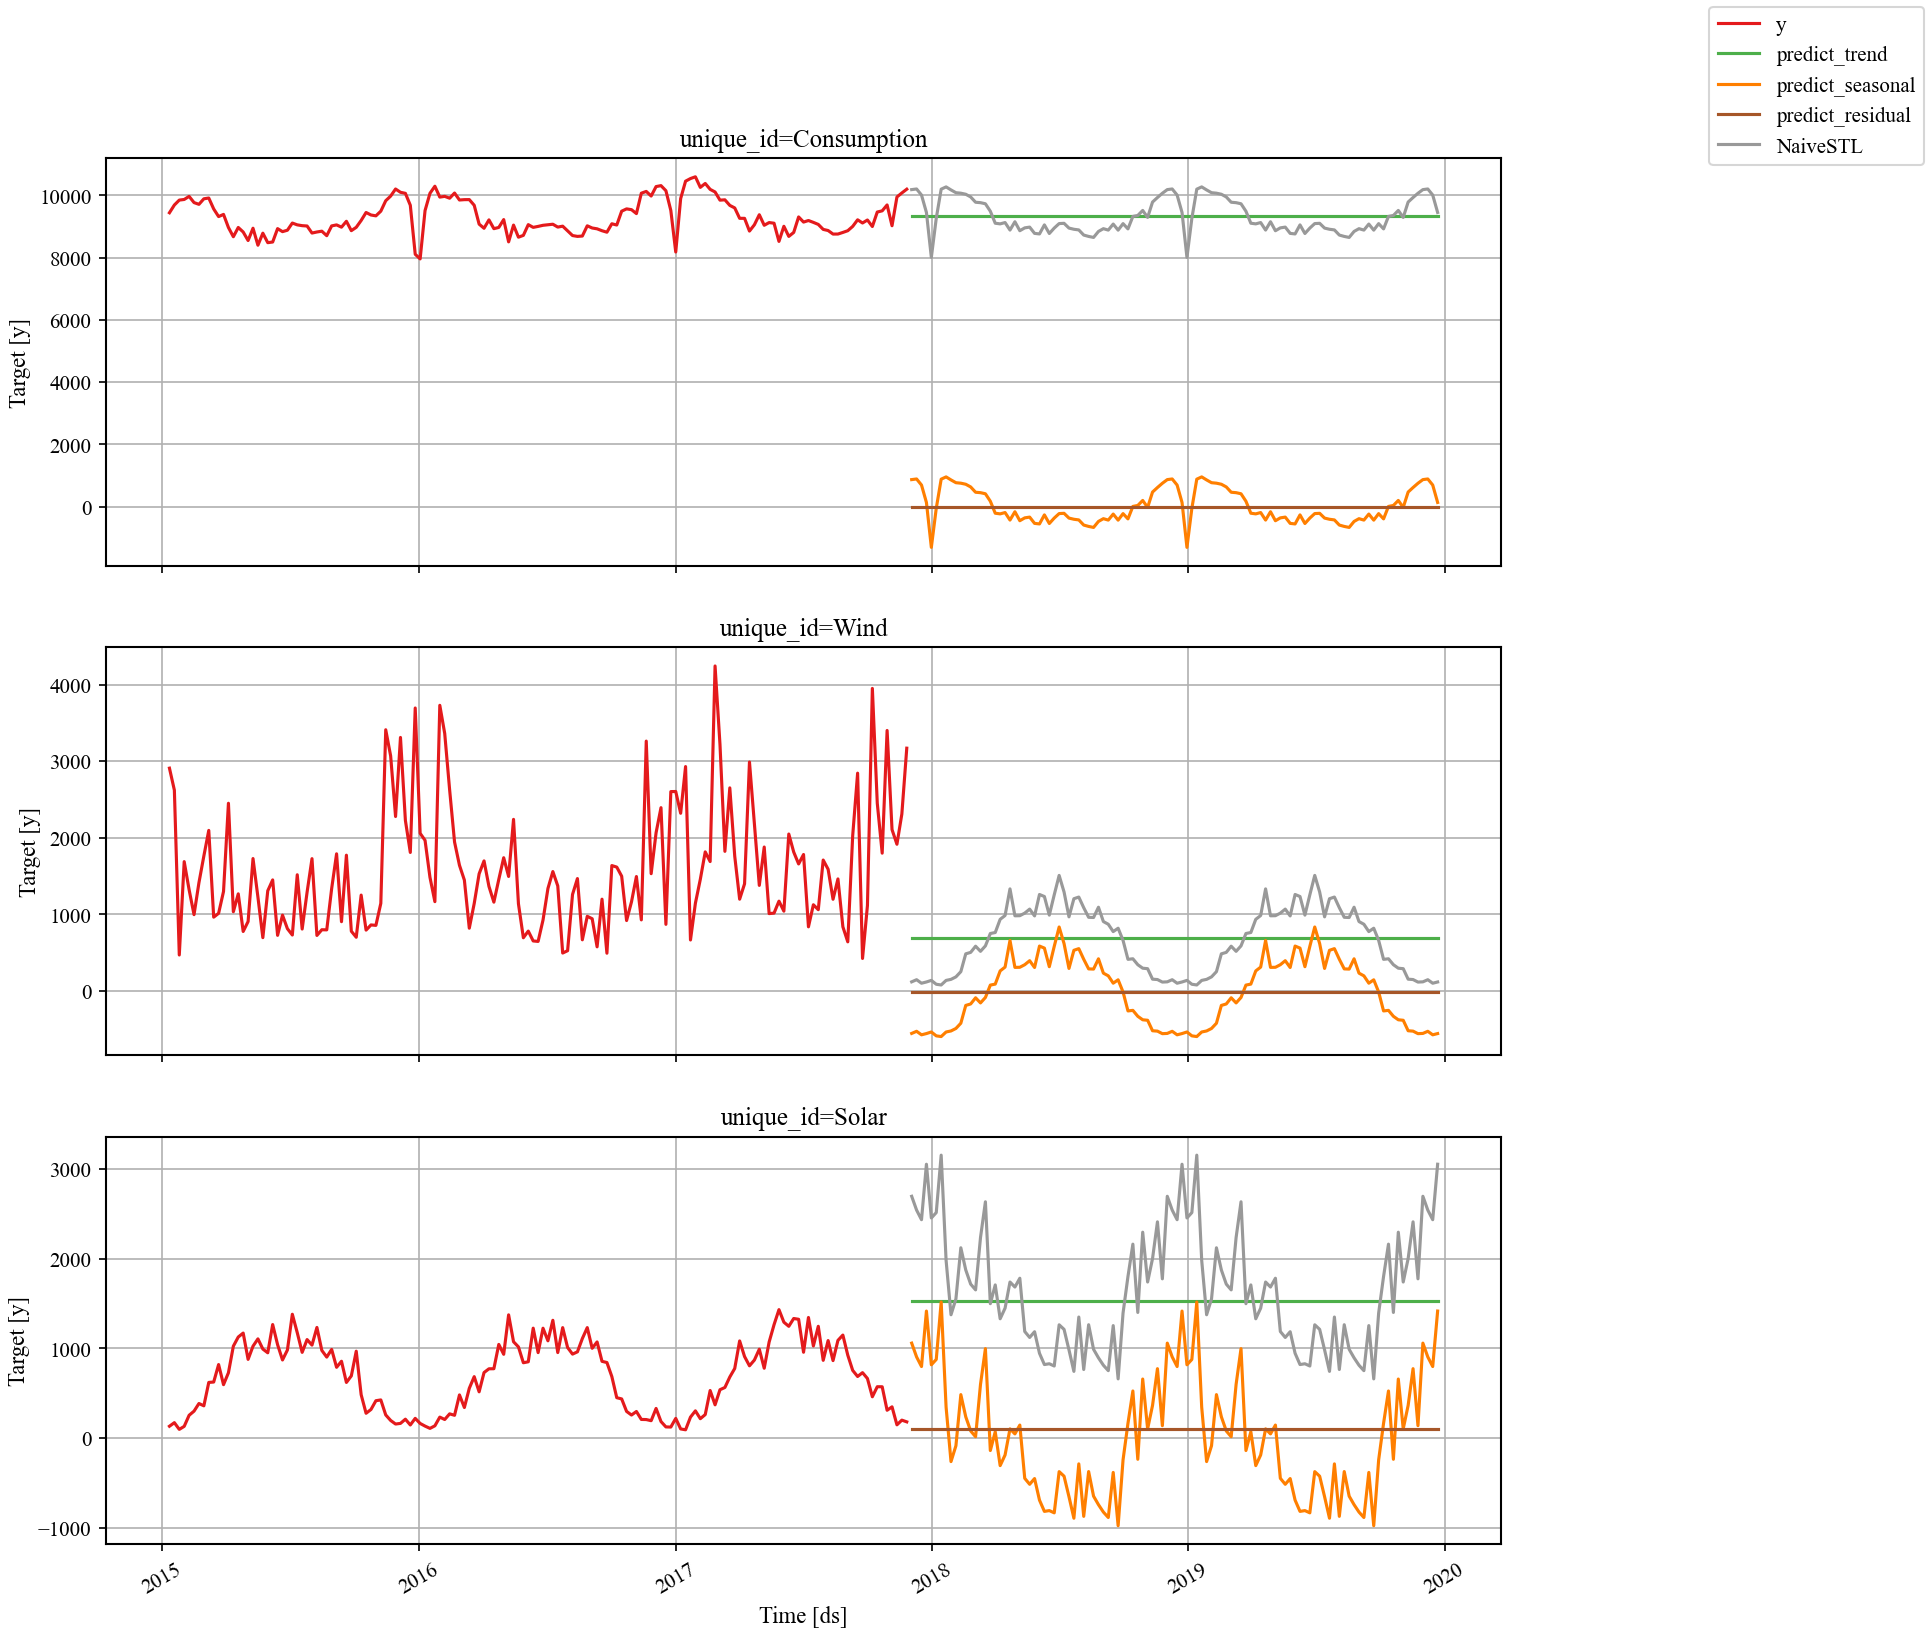

In [48]:
fig, ax = plt.subplots(3, 1, figsize=(12, 4*3), sharex=True)
plot_series(
    df_train,
    forecasts_df = fcst,
    ax=ax,
    palette='Set1',
)

#### Multiple STL - MSTL

Nixtla предоставляет реализацию [MSTL (Multiple Seasonal-Trend decomposition using LOESS)](https://nixtlaverse.nixtla.io/statsforecast/docs/models/multipleseasonaltrend.html) — расширение классического STL, способное одновременно моделировать несколько сезонных компонент (например, суточную и недельную). 

В экосистеме Nixtla в функцию MSTL интегрирован в прогнозный пайплайн: после выделения тренда и мульти-сезонности и остатка можно строить покомпонентный прогноз  с помощью  моделей (например, Naive, SeasonalNaive или ETS). 




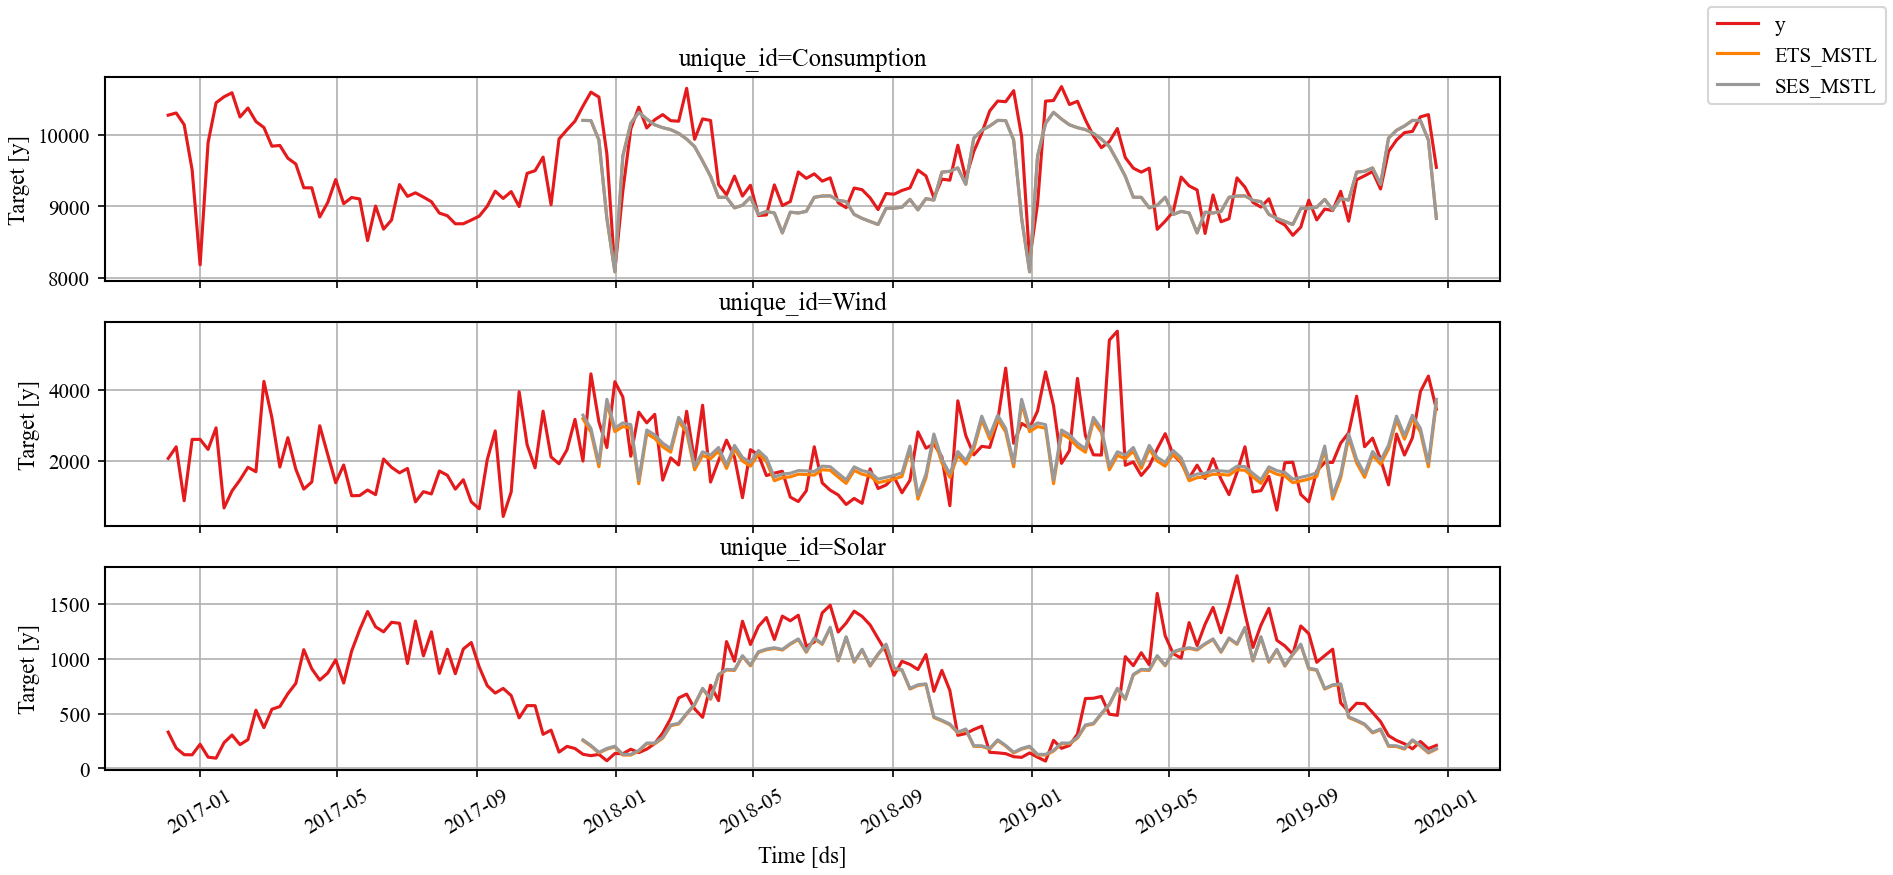

In [49]:
models = [ MSTL(season_length=[SEASON], alias = 'ETS_MSTL' ),
          MSTL(season_length=[SEASON],
               trend_forecaster=SimpleExponentialSmoothingOptimized(),
               alias = 'SES_MSTL' ),
         ]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, h=FH)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

alias = [x for x in fcst_sf.columns if not x in base_cols]

n_rows = eval_sf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(
    df_train,
    forecasts_df = eval_sf,
    ax=ax,
    max_insample_length = SEASON,
    palette='Set1',
)


In [50]:
metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
).pivot(
    index='metric',
    columns='unique_id',
    values=alias
)
metrics_sf_models

ETS_MSTL                            SES_MSTL              \
unique_id Consumption       Solar        Wind Consumption       Solar   
metric                                                                  
mase         1.263293    1.205407    0.911057    1.263263    1.186319   
rmse       335.003152  203.943524  969.349872  334.994069  200.526011   
smape        0.013718    0.128135    0.160751    0.013717    0.127030   

                       
unique_id        Wind  
metric                 
mase         0.922437  
rmse       955.855743  
smape        0.161919

Оба метода почти совпадают, что говорит о крайней простом тренде

#### Упражнение
1. Провести анализ метрик по подходам с разложением без него.

## Дополнительные методы






### MFLES

[MFLES](https://nixtlaverse.nixtla.io/statsforecast/docs/models/mfles.html) —  другим подходом, основанным на декомпозиции ВР ряда явлется модель MFLES. 
Модель реализует идею бустинга, он в специфике задач предсказания временных рядов. Модель автоматически последовательно улучшает прогноз, добавляя базовые компоненты: тренд, сезонность, и т.д. или усложняя метод для предсказания каждой из ее компонент.

In [51]:
from statsforecast.models import AutoMFLES, MFLES

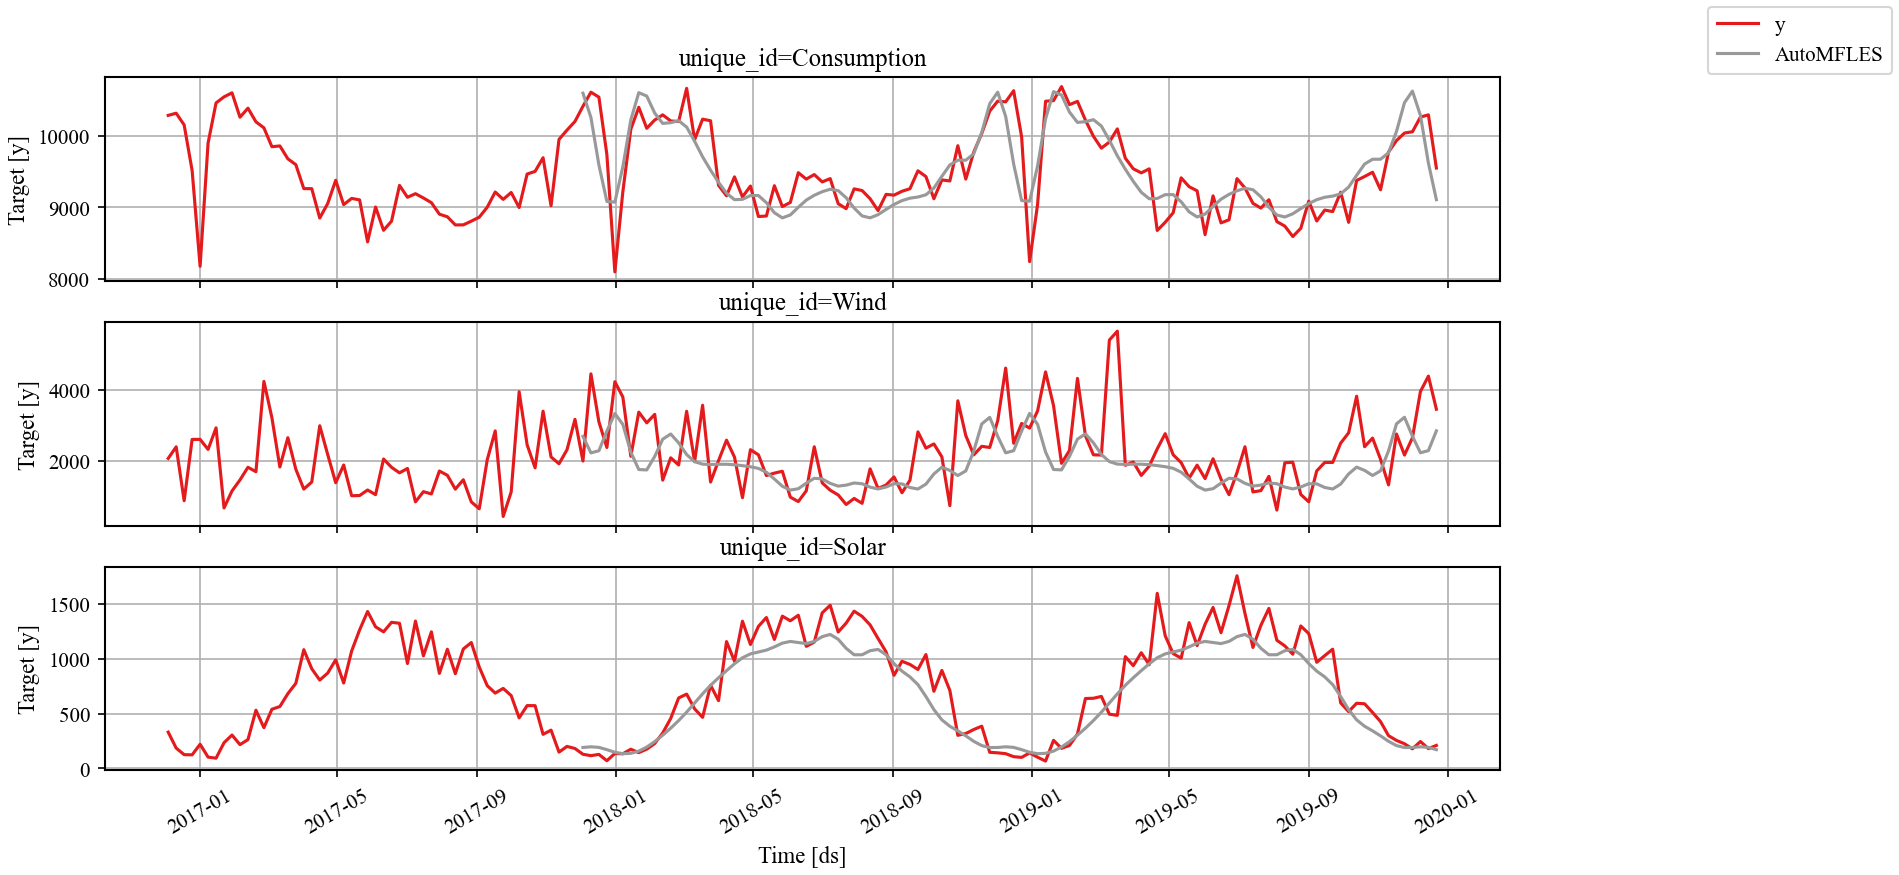

In [52]:
models = [ AutoMFLES(test_size = SEASON,
                     season_length = SEASON),]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, h=FH)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

alias = [x for x in fcst_sf.columns if not x in base_cols]

n_rows = eval_sf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(
    df_train,
    forecasts_df = eval_sf,
    ax=ax,
    max_insample_length = SEASON,
    palette='Set1',
)



### TBATS

Другим методом расширяющим семейство экпонециальных моделей является модели `BATS` и `TBATS`. Это методы, включающи в едином фреймровке несколько последовательных операций. Более того модели расширяют семейство экспоненциальных моделей, позволяя выделять в них несколько сезонных составляющих отдельно. Такие операции как:
* Преобразование [<tt>Box-Cox</tt>](https://otexts.com/fpp3/transformations.html)
* [Аппроксимация тренда](https://otexts.com/fpp3/regression.html),
* Выделение сезонных частей,
* описание остатков разложения в виде т.н. [<tt>ARMA</tt>](https://otexts.com/fpp3/arima.html) модели (она будет изучаться в следующих юнитах).
Описанная последовательность составляет модель [`BATS`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.bats.BATS.html). В модели [`TBATS`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.tbats.TBATS.html) к последовательности добавляется операция разложения сезонноых составляющих в ряд фурье и оценка коэффициентов для компонент ряда. Такая операция позволяет описать не стационарную сезонность.
В оригинале модели `BATS` и `TBATS` описаны [в отдельном фреймворке](https://github.com/intive-DataScience/tbats),  Однако Nixtla  предлагает [свою версию реализации этих моделей AutoTBATS](https://nixtlaverse.nixtla.io/statsforecast/src/core/models.html#autotbats).

>**BATS model** означает (Exponential smoothing state space model with Box-Cox transformation, ARMA errors, Trend and Seasonal components) \
> **TBATS model** означает (Exponential smoothing state space model with Box-Cox transformation, ARMA errors, Trend and Seasonal components)

In [53]:
from statsforecast.models import AutoTBATS, TBATS

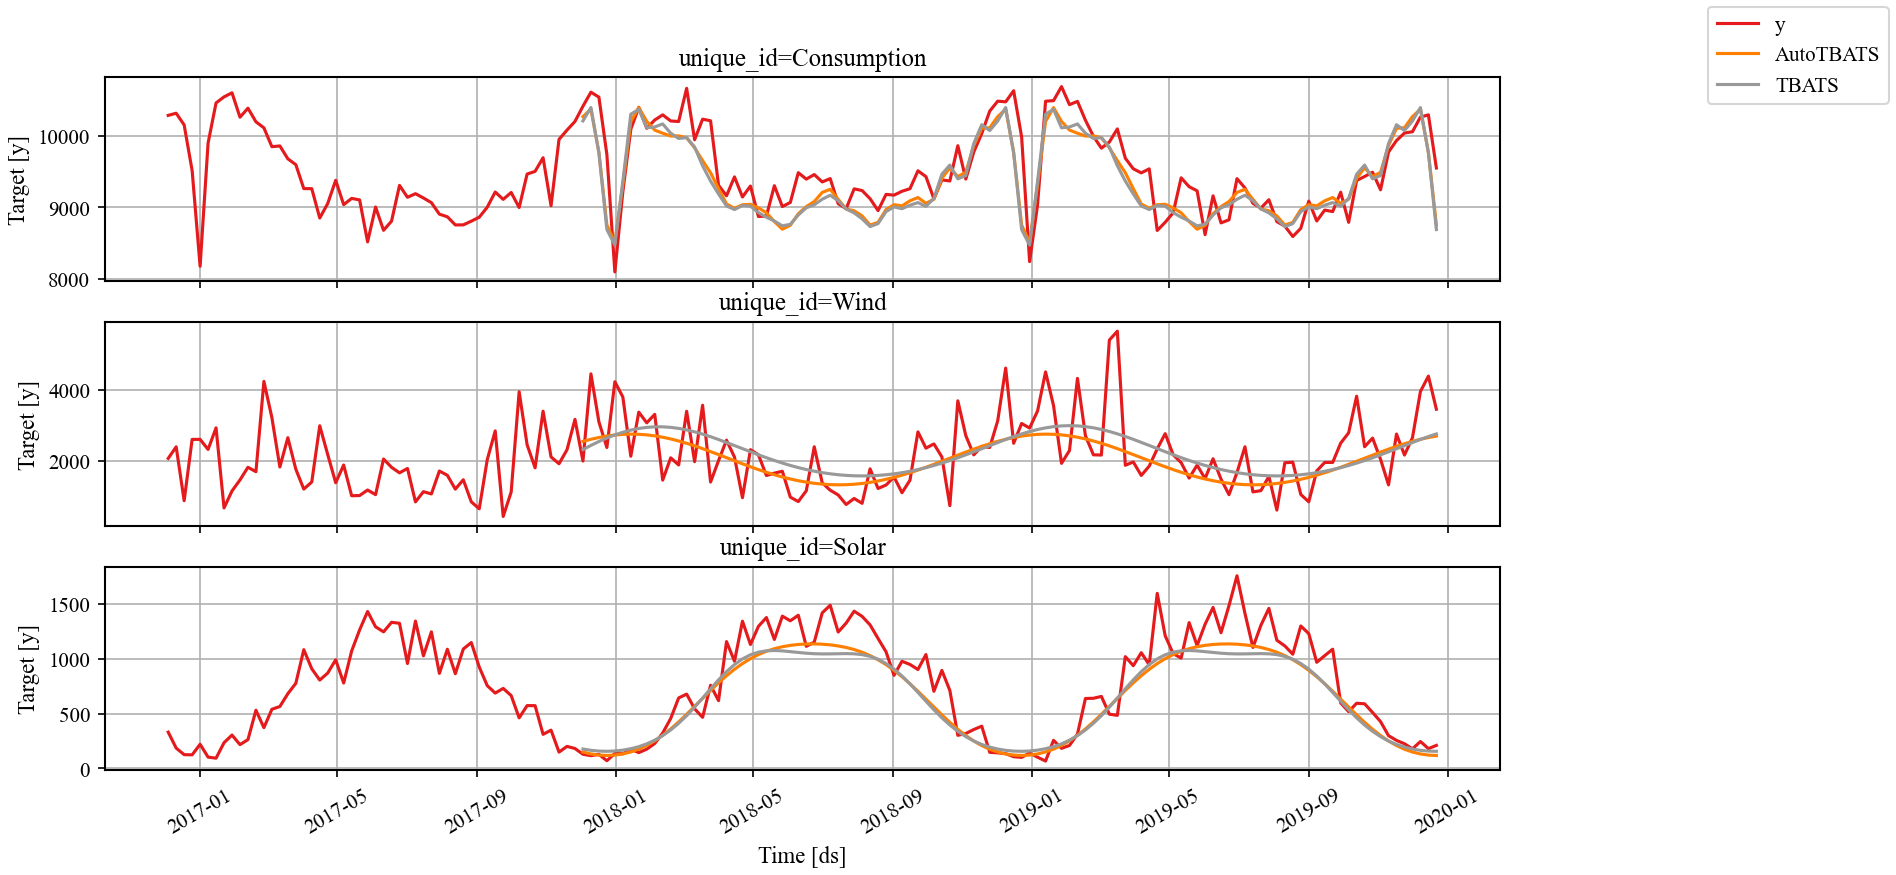

In [54]:
models = [AutoTBATS(season_length = SEASON),
          TBATS(season_length = SEASON,
                use_boxcox = True,
                bc_lower_bound = 0.0,
                bc_upper_bound = 0.1,
                use_trend = True,
                use_damped_trend = True,
                use_arma_errors = False,)]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, h=FH)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

alias = [x for x in fcst_sf.columns if not x in base_cols]

n_rows = eval_sf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(
    df_train,
    forecasts_df = eval_sf,
    ax=ax,
    max_insample_length = SEASON,
    palette='Set1',
)


### Prophet
В конце также рассмотрим пример метода обобщенной регрессии: `Prophet`. Напомним, что это метод предсказания временных рядов на основе т.н. обобщенной регрессии для модели бизнес процессов, которая включает тренд с точками перегиба и насыщением, несколько компонент сезонности и редкие, но регулярные события (типа выходных дней). 
> Отметим что модель является не единственной в своем классе, однако одной из наиболее популярных. В том числе модель может быть расширена для преодоления своих недостатков при помощи модели [`neural prophet`](https://github.com/ourownstory/neural_prophet). А также могут быть пострены свои [<tt>prophet</tt>-подобные](https://www.pymc.io/projects/examples/en/latest/time_series/Air_passengers-Prophet_with_Bayesian_workflow.html) модели.

<!-- https://habr.com/ru/companies/otus/articles/555700/ -->

In [55]:
# from statsforecast.adapters.prophet import AutoARIMAProphet
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.fbprophet import Prophet

In [56]:
def nixtla_forecast_with_prophet(forecaster, df_train, df_test):
    results_list = []

    for (name, y_train), (name, y_test) in zip(df_train.groupby('unique_id'), df_test.groupby('unique_id')):
        y_train.index = pd.to_datetime(y_train['ds'])
        y_train = y_train.drop(columns=['unique_id', 'ds'])

        y_test.index = pd.to_datetime(y_test['ds'])
        y_test = y_test.drop(columns=['unique_id', 'ds'])

        forecaster.fit(y_train)
        fh = ForecastingHorizon(y_test.index, is_relative=False)
        y_pred = forecaster.predict(fh)

        # Преобразуем в нужный формат, убедившись, что yhat — одномерный
        temp_df = pd.DataFrame({
            'unique_id': [name] * len(y_pred),
            'ds': y_pred.index,
            'Prophet': y_pred.values.flatten()  # flatten() гарантирует 1D
        })
        results_list.append(temp_df)

    fcst_sf = pd.concat(results_list, ignore_index=True)
    return fcst_sf

In [57]:
forecaster = Prophet(seasonality_mode='additive',
                         n_changepoints=int(len(df_train) / 4),
                         add_country_holidays={'country_name': 'Germany'},
                         yearly_seasonality=True)

fcst_sf = nixtla_forecast_with_prophet(forecaster, df_train, df_test)

18:54:04 - cmdstanpy - INFO - Chain [1] start processing
18:54:04 - cmdstanpy - INFO - Chain [1] done processing
18:54:04 - cmdstanpy - INFO - Chain [1] start processing
18:54:04 - cmdstanpy - INFO - Chain [1] done processing
18:54:04 - cmdstanpy - INFO - Chain [1] start processing
18:54:04 - cmdstanpy - INFO - Chain [1] done processing


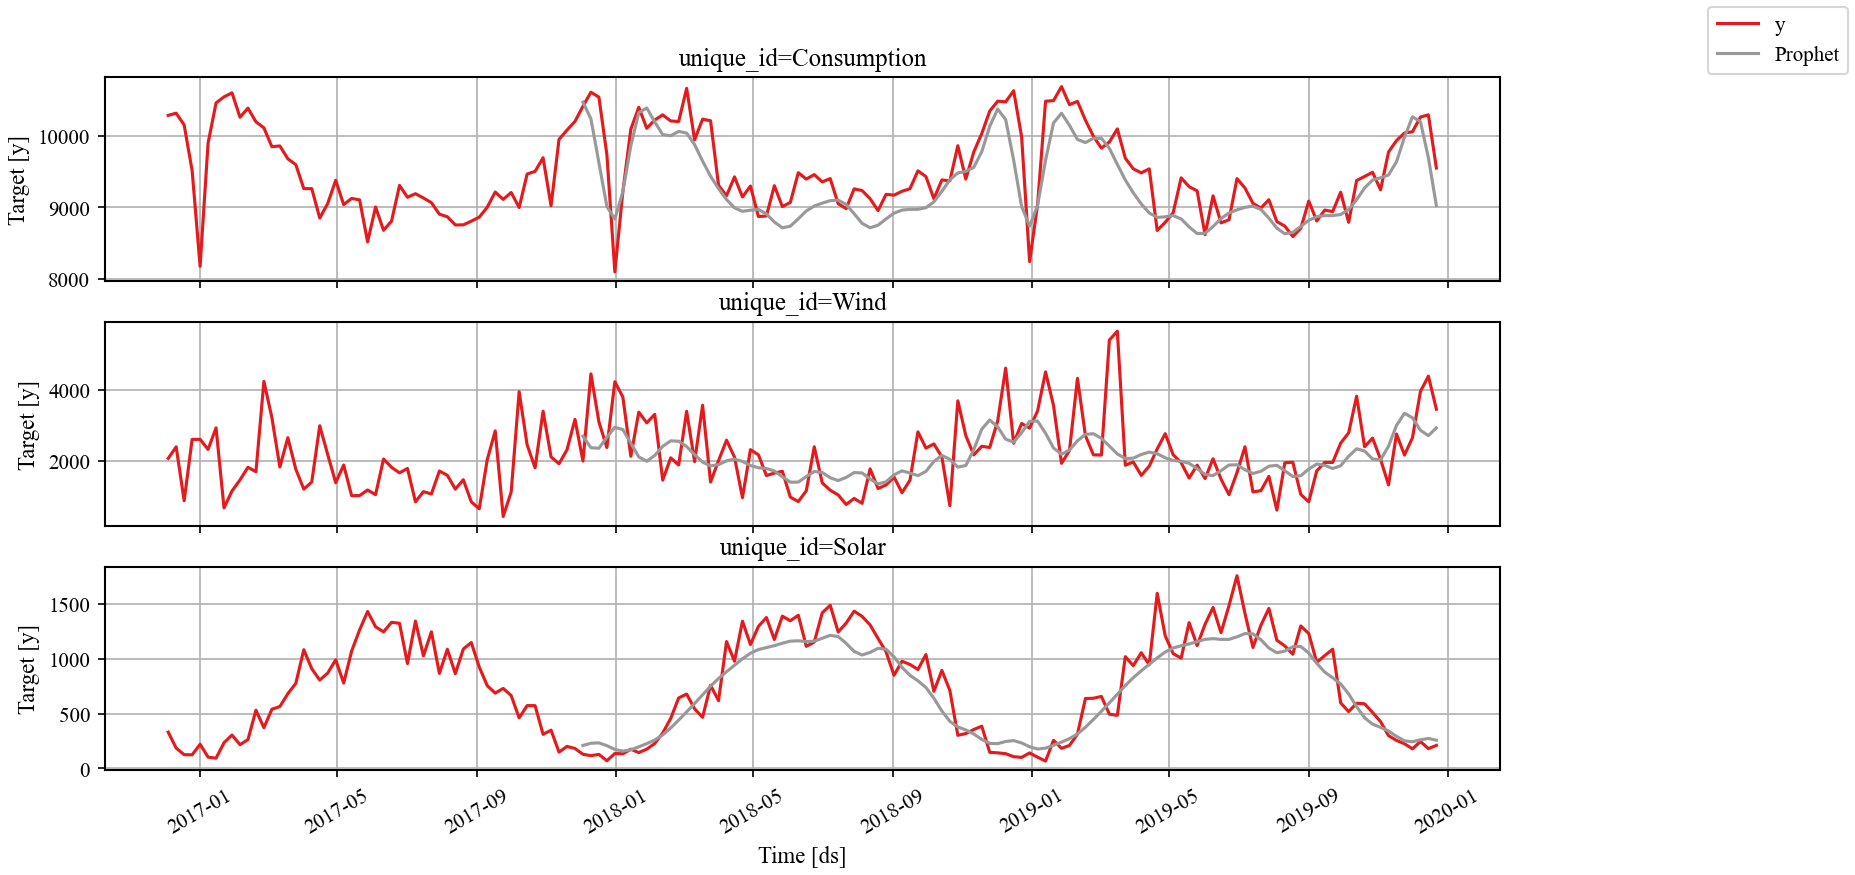

In [58]:
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

alias = [x for x in fcst_sf.columns if not x in base_cols]

n_rows = eval_sf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(
    df_train,
    forecasts_df = eval_sf,
    ax=ax,
    max_insample_length = SEASON,
    palette='Set1',
)


In [60]:
metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
).pivot(
    index='metric',
    columns='unique_id',
    values=alias
)
metrics_sf_models

Prophet                        
unique_id Consumption       Solar        Wind
metric                                       
mase         1.399934    1.040454    0.820650
rmse       366.735751  176.799369  876.796013
smape        0.015232    0.117217    0.143059

In [61]:
metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
)
metrics_sf_models

,unique_id,metric,Prophet
0,Consumption,mase,1.399934
1,Solar,mase,1.040454
2,Wind,mase,0.820650
3,Consumption,rmse,366.735751
4,Solar,rmse,176.799369
5,Wind,rmse,876.796013
6,Consumption,smape,0.015232
7,Solar,smape,0.117217
8,Wind,smape,0.143059


## Многосезонный ВР

### Задание ряда с шагом в 1 день


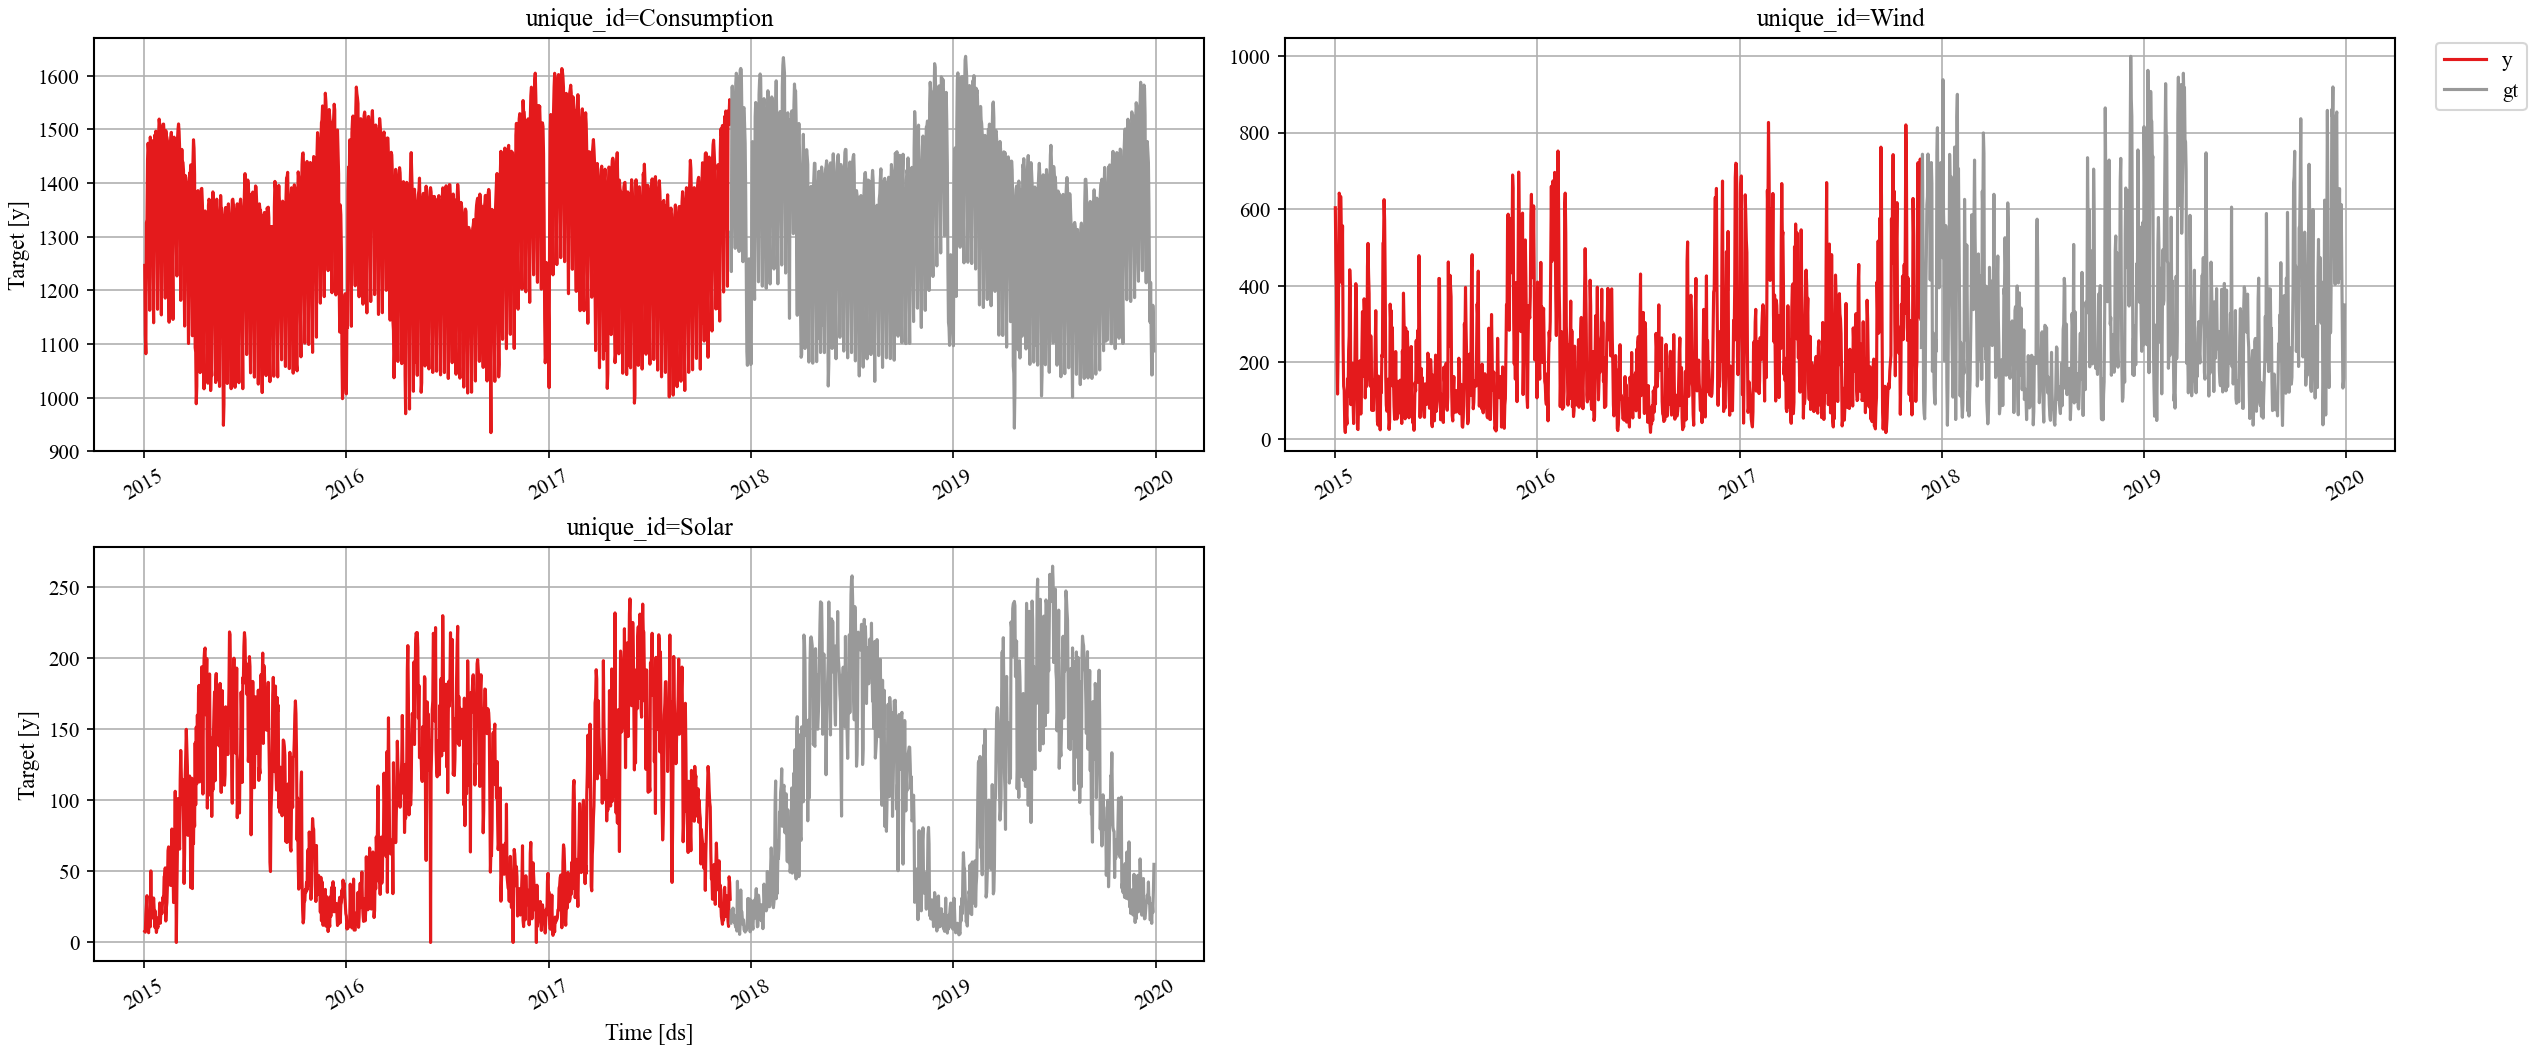

In [60]:
y = df_.resample('D').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq

# SEASON = find_season_length(y['Consumption'].values, max_season_length = 55)
SEASON = [7,365] # 53 недели в году

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

### Модели для теста на предсказание многосезонных данных

In [61]:
models = [SeasonalExponentialSmoothingOptimized(season_length = SEASON[-1]),
          MSTL(season_length=SEASON, ),
          AutoETS(season_length=SEASON[-1], model='ZZA', damped = False, alias='ETS'),
          TBATS(season_length = SEASON,
                        use_boxcox = True,
                        bc_lower_bound = 0.0,
                        bc_upper_bound = 1,
                        use_trend = True,
                        use_damped_trend = True,
                        use_arma_errors = False,),
         ]

In [62]:
sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, h=FH)


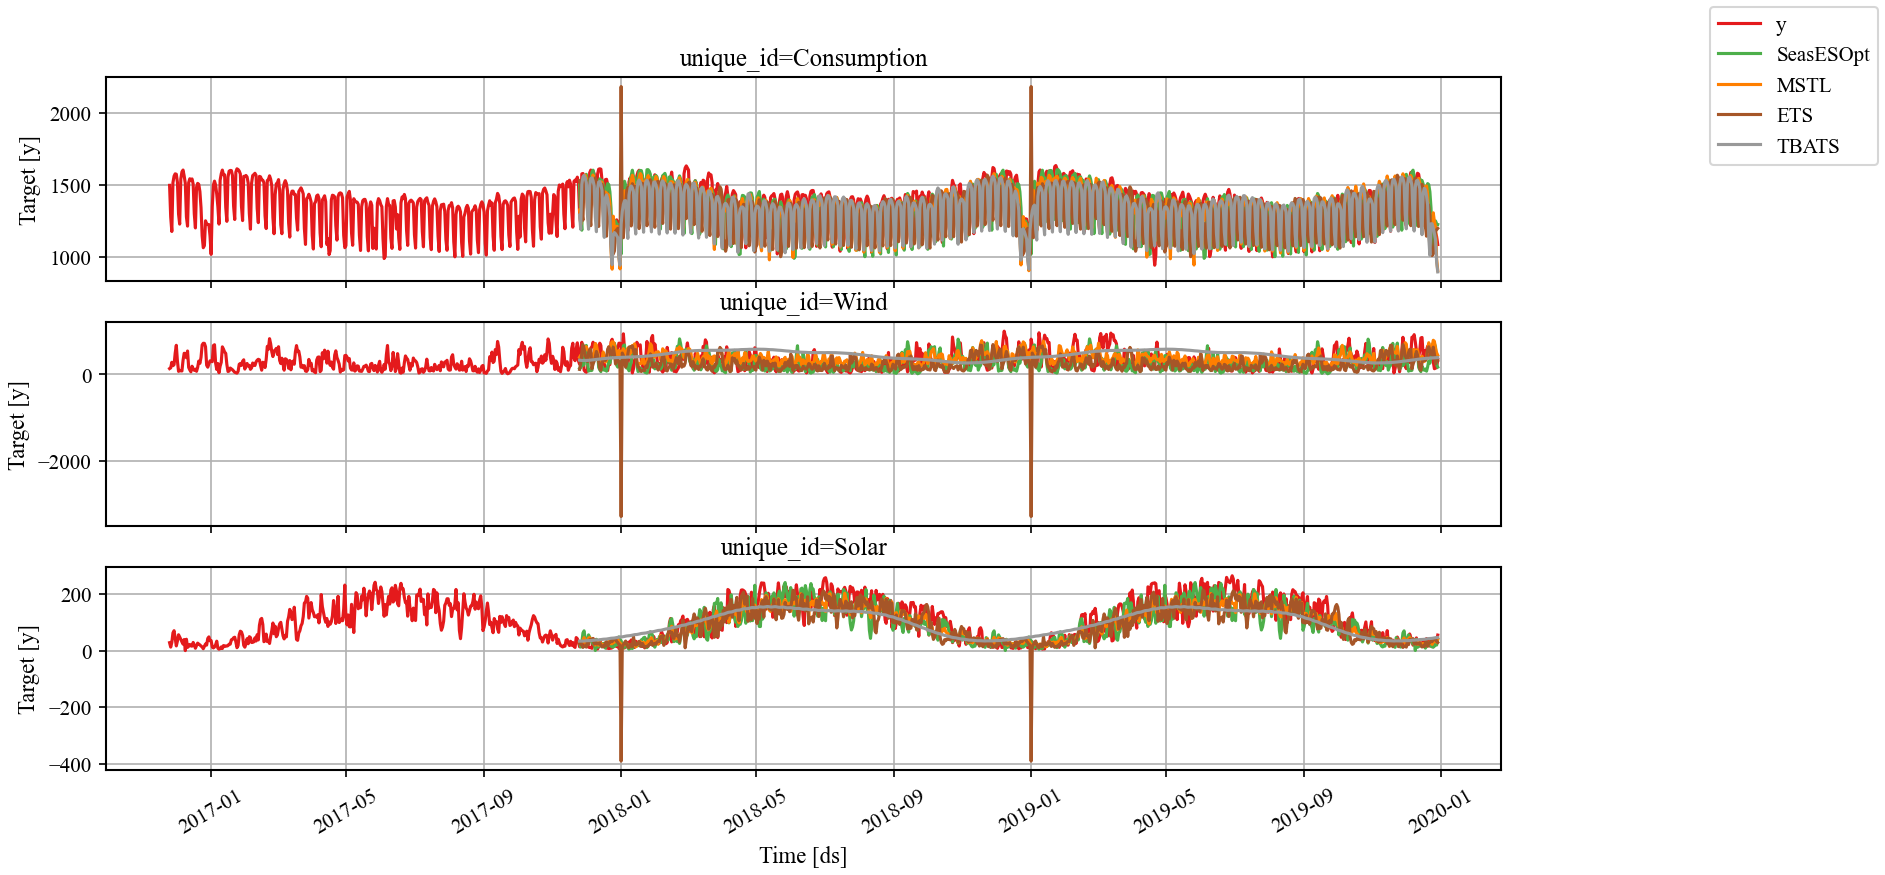

In [63]:
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

alias = [x for x in fcst_sf.columns if not x in base_cols]

n_rows = eval_sf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(
    df_train,
    forecasts_df = eval_sf,
    ax=ax,
    max_insample_length = SEASON[-1],
    palette='Set1',
)


### Prophet

In [64]:
forecaster = Prophet(
    seasonality_mode='additive',
    seasonality_prior_scale=0.5,  # уменьшили — сезонность будет мягче
    changepoint_prior_scale=0.01,  # уменьшили — тренд будет мягче
    add_country_holidays={'country_name': 'Germany'},
    weekly_seasonality=True,
    yearly_seasonality=True
)


fcst_sf = nixtla_forecast_with_prophet(forecaster, df_train, df_test)



16:26:10 - cmdstanpy - INFO - Chain [1] start processing
16:26:10 - cmdstanpy - INFO - Chain [1] done processing
16:26:10 - cmdstanpy - INFO - Chain [1] start processing
16:26:10 - cmdstanpy - INFO - Chain [1] done processing
16:26:10 - cmdstanpy - INFO - Chain [1] start processing
16:26:10 - cmdstanpy - INFO - Chain [1] done processing


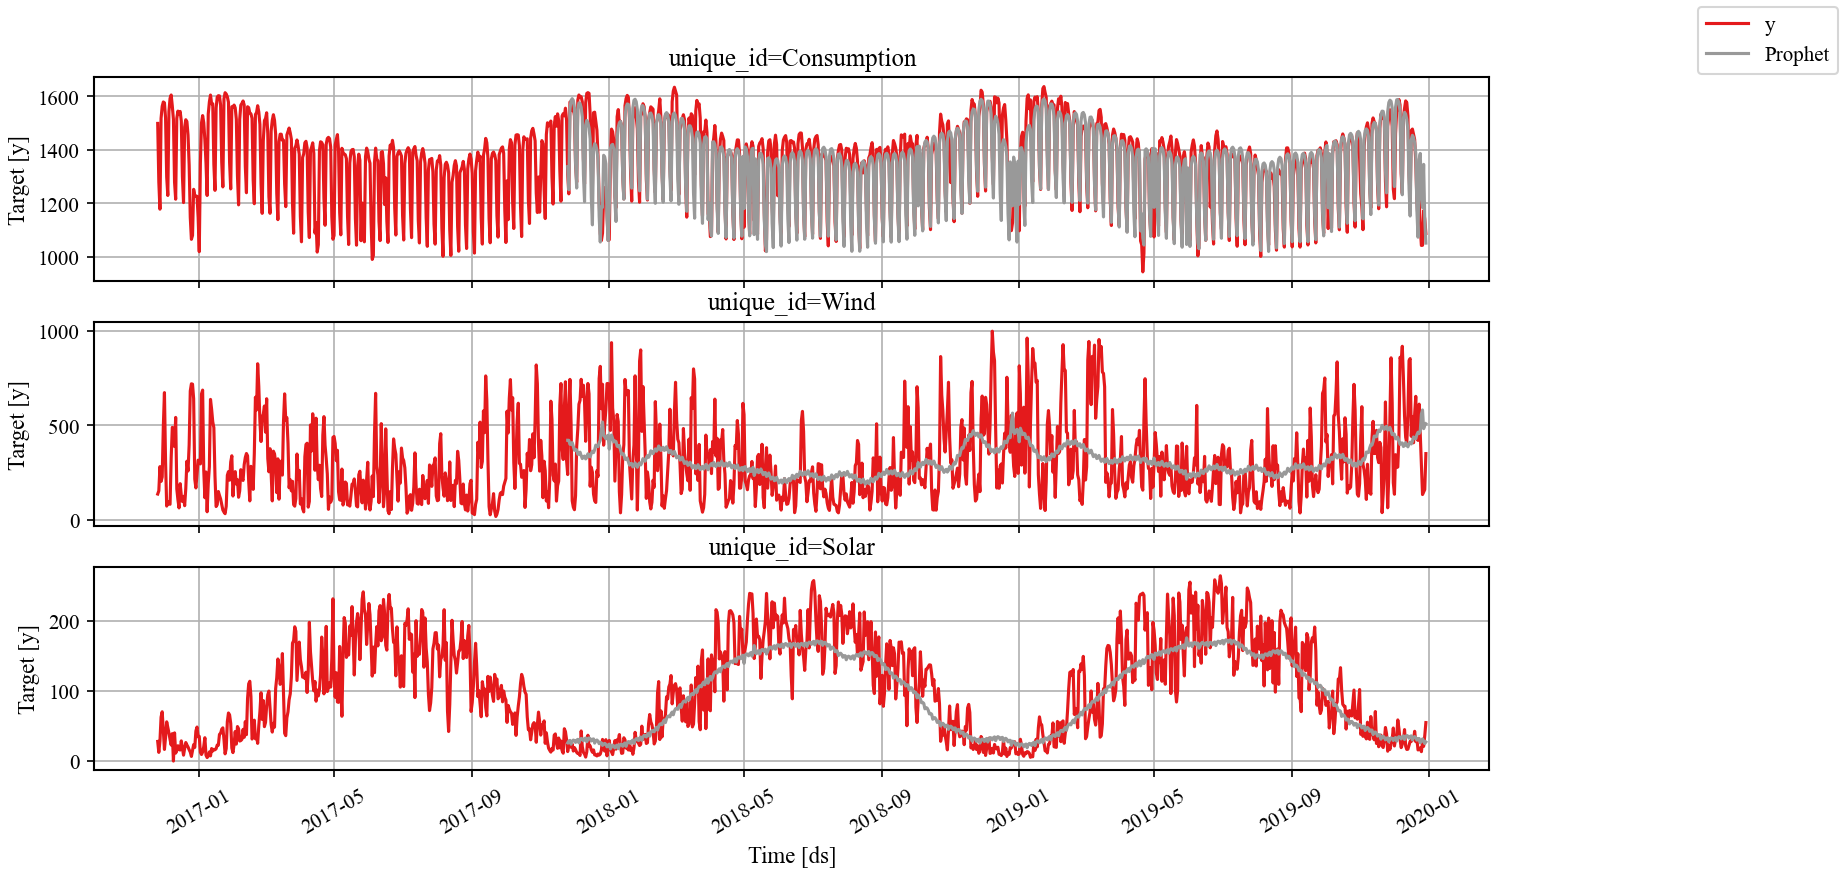

In [65]:
eval_sf_ = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

alias = [x for x in fcst_sf.columns if not x in base_cols]

n_rows = eval_sf_['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(
    df_train,
    forecasts_df = eval_sf_,
    ax=ax,
    max_insample_length = SEASON[-1],
    palette='Set1',
)


### Оценка точности

In [66]:
eval_sf_ = eval_sf.merge(fcst_sf, on=['unique_id', 'ds'])
eval_sf_

,unique_id,ds,y,SeasESOpt,MSTL,ETS,TBATS,Prophet
0,Consumption,2017-11-25,1308.524,1503.141077,1327.479808,1531.298680,1291.416276,1336.739216
1,Consumption,2017-11-26,1235.120,1281.440656,1226.322355,1498.578178,1193.032829,1250.355897
2,Consumption,2017-11-27,1578.479,1186.783159,1503.490208,1315.279085,1504.719619,1552.163743
3,Consumption,2017-11-28,1580.846,1514.764680,1527.962809,1256.113246,1557.840396,1584.830097
4,Consumption,2017-11-29,1546.290,1562.261792,1555.768162,1538.989547,1568.231450,1591.256866
...,...,...,...,...,...,...,...,...
2290,Solar,2019-12-25,13.417,12.302295,29.795901,42.617966,44.220128,28.368037
2291,Solar,2019-12-26,27.332,15.694745,34.370628,38.101770,45.167786,31.694881
2292,Solar,2019-12-27,20.958,23.630597,38.089676,41.418819,45.951763,28.677707
2293,Solar,2019-12-28,36.239,19.579827,29.640492,32.583273,46.399709,25.049514


In [67]:
alias = [x for x in eval_sf.columns if not x in base_cols]

metrics_sf_models = evaluate(
    df=eval_sf_,
    metrics=metrics,
    train_df=df_train,)\
#     .pivot(
#     index='metric',
#     columns='unique_id',
#     values=alias
# )
pd.set_option('display.precision', 3)
metrics_sf_models.sort_values(by='metric') 

,unique_id,metric,SeasESOpt,MSTL,ETS,TBATS,Prophet
0,Consumption,mase,0.701,0.237,0.893,0.249,0.185
1,Solar,mase,0.679,0.581,0.661,0.683,0.542
2,Wind,mase,1.228,1.133,1.162,1.460,0.943
3,Consumption,rmse,189.766,69.148,225.361,68.918,51.864
4,Solar,rmse,48.523,40.294,49.891,44.734,36.944
5,Wind,rmse,261.228,228.464,319.080,273.652,198.274
6,Consumption,smape,0.055,0.019,0.070,0.019,0.014
7,Solar,smape,0.212,0.179,0.203,0.218,0.167
8,Wind,smape,0.343,0.281,0.307,0.336,0.250


### Почасовые предсказания

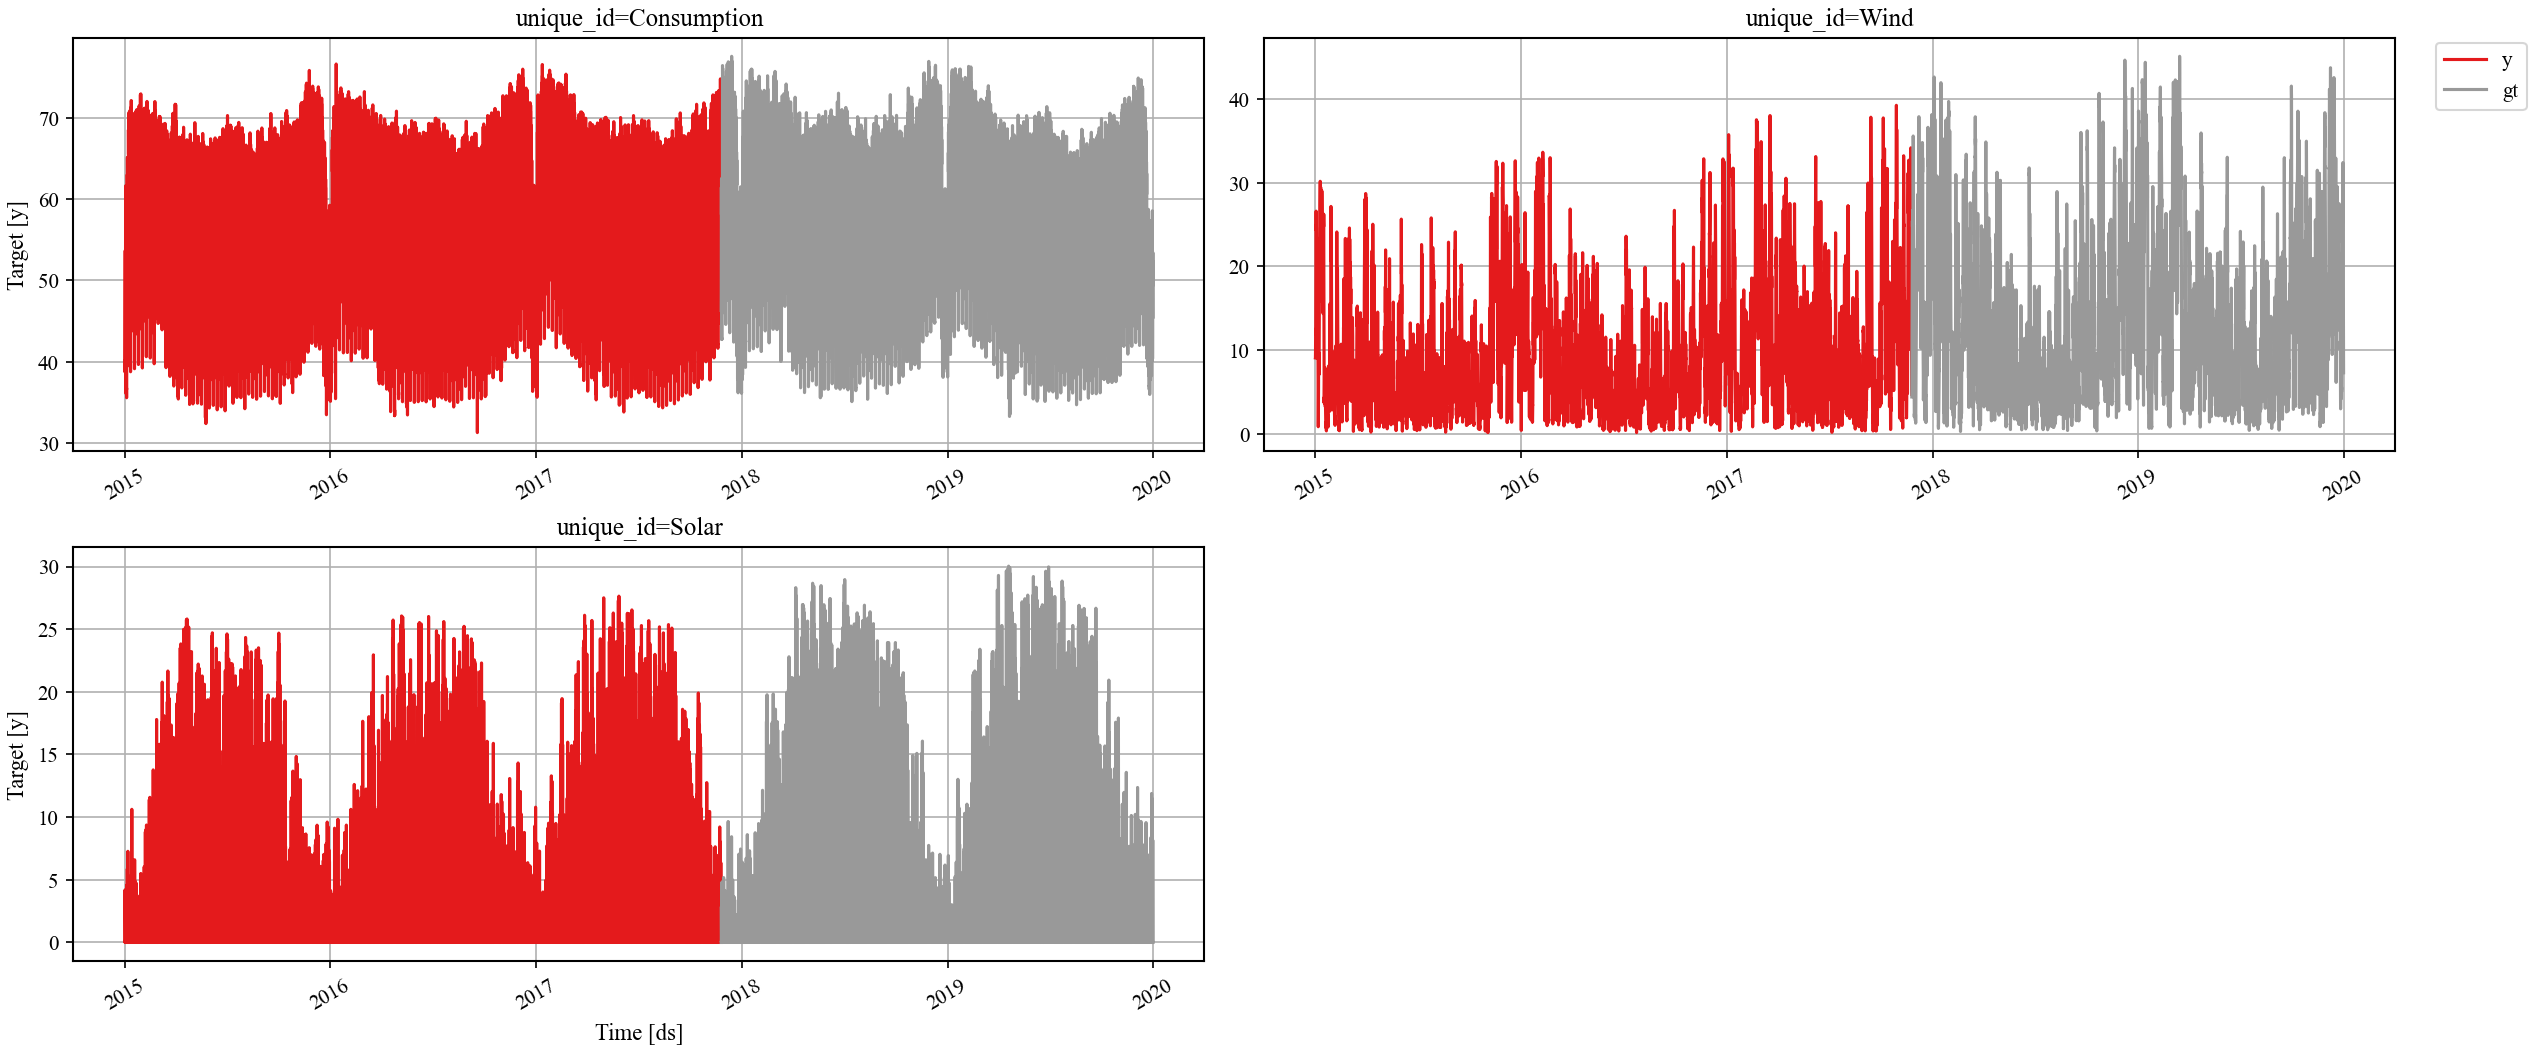

In [68]:
y = df_.resample('h').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = [24,24*7,int(24*365.25)] 

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [69]:
models = [SeasonalExponentialSmoothingOptimized(season_length = SEASON[-1]),
          # MSTL(season_length=SEASON, ),
          # AutoETS(season_length=SEASON[-1], model='ZZA', damped = False, alias='ETS'),
          # TBATS(season_length = SEASON,
          #               use_boxcox = True,
          #               bc_lower_bound = 0.0,
          #               bc_upper_bound = 1,
          #               use_trend = True,
          #               use_damped_trend = True,
          #               use_arma_errors = False,),
         ]

In [70]:
sf = StatsForecast(
    models=models,
    freq=FREQ,
    
)

fcst_sf = sf.forecast(df=df_train, h=FH)

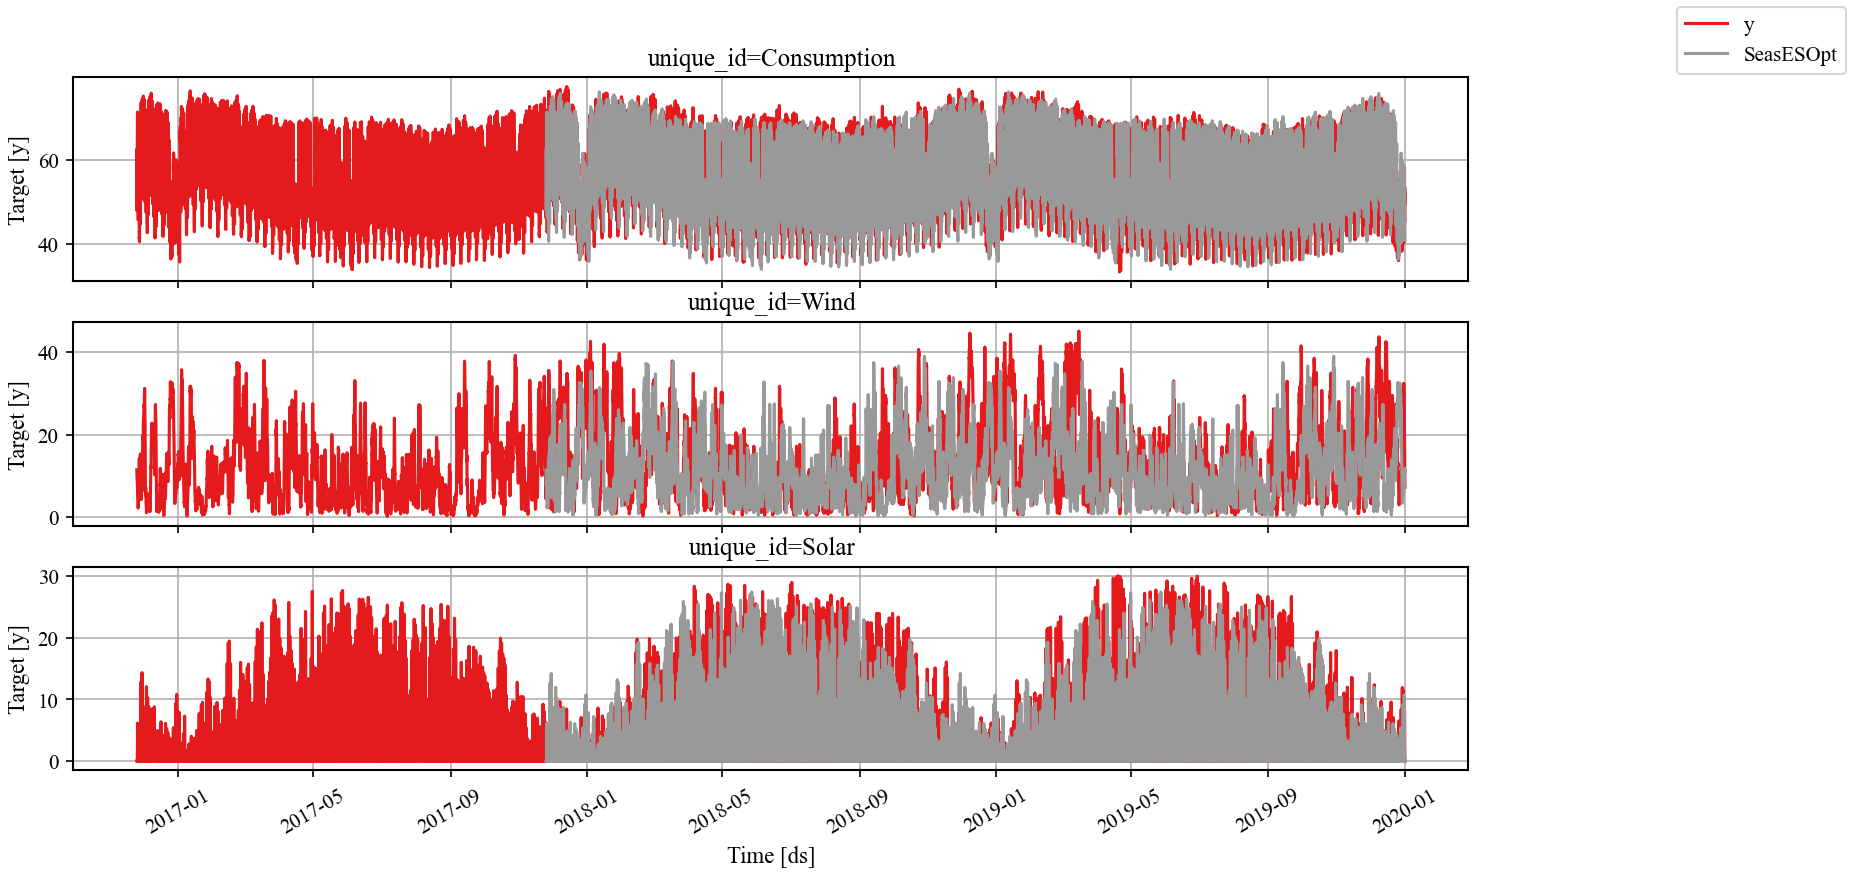

In [71]:
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

alias = [x for x in fcst_sf.columns if not x in base_cols]

n_rows = eval_sf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(
    df_train,
    forecasts_df = eval_sf,
    ax=ax,
    max_insample_length = SEASON[-1],
    palette='Set1',
)


In [76]:
forecaster = Prophet(
    seasonality_mode='additive',
    seasonality_prior_scale=0.9,  # уменьшили — сезонность будет мягче
    changepoint_prior_scale=0.01,  # уменьшили — тренд будет мягче
    add_country_holidays={'country_name': 'Germany'},
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=True,
)


fcst_sf = nixtla_forecast_with_prophet(forecaster, df_train, df_test)

16:28:04 - cmdstanpy - INFO - Chain [1] start processing
16:28:07 - cmdstanpy - INFO - Chain [1] done processing
16:28:12 - cmdstanpy - INFO - Chain [1] start processing
16:28:13 - cmdstanpy - INFO - Chain [1] done processing
16:28:18 - cmdstanpy - INFO - Chain [1] start processing
16:28:20 - cmdstanpy - INFO - Chain [1] done processing


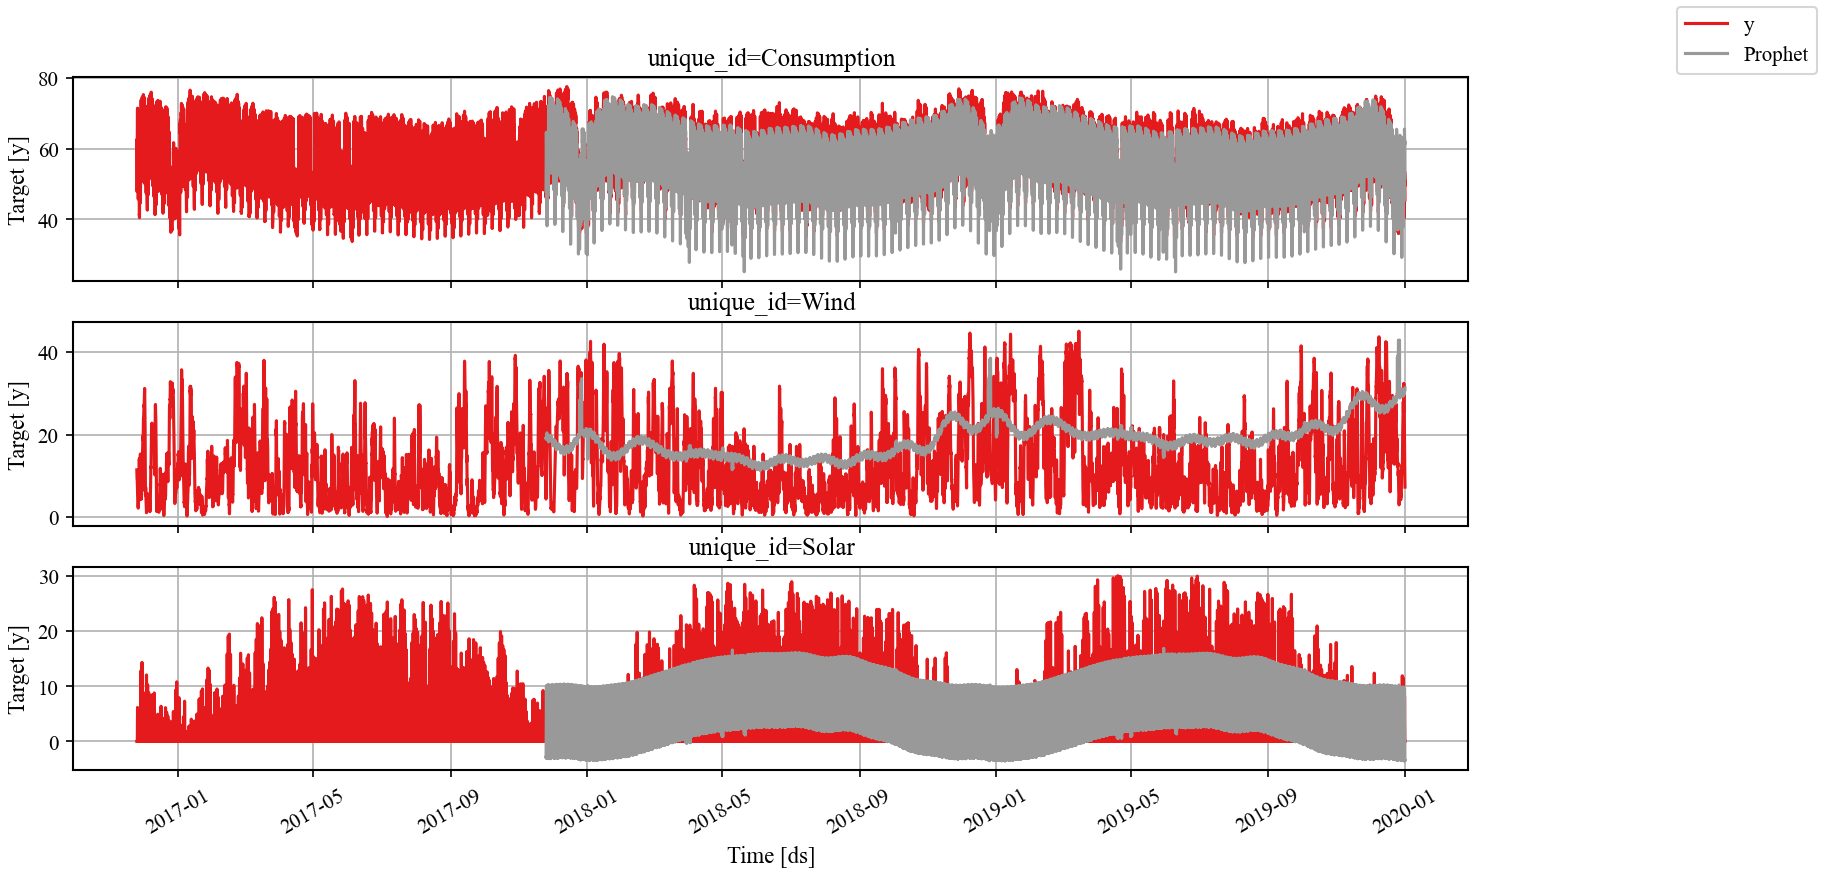

In [77]:
eval_sf_ = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

alias = [x for x in fcst_sf.columns if not x in base_cols]

n_rows = eval_sf_['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(
    df_train,
    forecasts_df = eval_sf_,
    ax=ax,
    max_insample_length = SEASON[-1],
    palette='Set1',
)


In [73]:
eval_sf_ = eval_sf.merge(fcst_sf, on=['unique_id', 'ds'])

In [74]:
alias = [x for x in eval_sf.columns if not x in base_cols]

metrics_sf_models = evaluate(
    df=eval_sf_,
    metrics=metrics,
    train_df=df_train,)\
#     .pivot(
#     index='metric',
#     columns='unique_id',
#     values=alias
# )
pd.set_option('display.precision', 3)
metrics_sf_models.sort_values(by='metric') 

,unique_id,metric,SeasESOpt,Prophet
0,Consumption,mase,1.139,0.270
1,Solar,mase,1.669,0.662
2,Wind,mase,1.423,1.458
3,Consumption,rmse,14.577,3.694
4,Solar,rmse,10.195,3.811
5,Wind,rmse,11.896,10.892
6,Consumption,smape,0.109,0.027
7,Solar,smape,0.859,0.646
8,Wind,smape,0.382,0.335


#### Упражнение
1. Проверить возможность построения прогноза для отдельных компонент ВР с часовым шагом.